# FORMATIVE ASSESSMENT OF ADOLESCENT GIRLS AND YOUNG WOMEN’S HIV, GENDER-BASED VIOLENCE AND SEXUAL AND REPRODUCTIVE HEALTH STATUS

## Background
Teenage pregnancy and motherhood have been a major health and social concern in Uganda as it infringes upon the human rights of girls but also hinders their ability to achieve their full socioeconomic development. Teenagers who engage in sexual intercourse at a young age face an elevated risk of becoming pregnant and giving birth. The 2022 UDHS indicated that 23.5% of women age 15-19 had initiated childbearing by the time of the survey, with 18.4% having already had a live birth, while 5.1% were pregnant with their first child.

Patterns by background characteristics:
* By age 16, 1 in every 10 women age 15-19 has begun childbearing. This percentage significantly rises to almost 4 out of every 10 by the time they reach 18 (Table 5.12).
* Teenagers in rural areas started childbearing earlier than those in urban areas. Twenty five percent of women age 15-19 in rural areas have begun childbearing, compared with 21% in urban areas.
* Teenage childbearing varies by region. The percentage of women age 15-19 who have begun childbearing ranges from 15% in Kigezi region to 28 % -30% in Busoga and Bukedi sub regions.
* The proportion of women age 15-19 who have begun childbearing decreases with both education and wealth.

Regions: The selection of the districts that we surveyed was informed by HIV prevalence dynamics and implementing partner support: we went to districts where there were Global Fund-supported implementing partners working to reduce the new number of new HIV infections among AGYW, improve SRH (e.g. reduce teenage pregnancy) and GBV indicators in the targeted districts.

## Sampling
Here we compare cases with controls:
* **Cases** are girls who experienced pregnancy at ≤ 19 (exposure group). By excluding pregnancies after 19, we isolate adolescent pregnancies.
* **Controls** Girls who never became pregnant and are ≥ 20 now. This matters because if we included younger girls (e.g., 15, 16, 17) who haven’t been pregnant yet, they might still become pregnant during adolescence. They’re not “true controls” because their outcome is not yet determined. By requiring ≥ 20, we ensure they’ve passed the “risk window” for adolescent pregnancy. This makes them valid comparators.

## Data Set-Up

The output of this notebook includes a data analysis responding to the research questions.

### Set Environment and Load Data

In [1]:
import warnings
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from scipy import stats
from scipy.stats import zscore, chi2_contingency, fisher_exact, spearmanr
from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from lifelines import KaplanMeierFitter
from matplotlib.ticker import PercentFormatter, MaxNLocator
import yaml

# Repo root — works whether the notebook is run from notebooks/ or from root
here = Path().resolve()
REPO_ROOT = here.parent if here.name == 'notebooks' else here
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

# Load config
with open('config.yaml') as f:
    cfg = yaml.safe_load(f)

# Project helpers
from src.utils import (
    wilson_ci, add_prev_ci, cramers_v, pformat, build_block_chi2,
    km_incidence_at, or_ci, tidy_or_table, summarize_methods, mean_sd, fit_model,
)

# Display settings
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid", context="paper")
warnings.filterwarnings("ignore")

# Plot constants (from config)
MIN_N      = cfg['plot']['MIN_N']
FIGSIZE    = tuple(cfg['plot']['FIGSIZE'])
FONTSIZE   = cfg['plot']['FONTSIZE']
LINEWIDTH  = cfg['plot']['LINEWIDTH']
MARKERSIZE = cfg['plot']['MARKERSIZE']
CAPSIZE    = cfg['plot']['CAPSIZE']
TEEN_ONLY  = cfg['plot']['TEEN_ONLY']
BAR_H      = cfg['plot']['BAR_H']

# Data constants (from config)
VALID_STATUS = cfg['data']['valid_school_statuses']

print("Working directory:", os.getcwd())

Current directory: /Users/nataschajademinnitt/Documents/5_data/teenage_pregnancy


In [2]:
# Load the data
df18 = pd.read_csv("./data/processed_df_2018_aligned.csv")
df23 = pd.read_csv("./data/processed_df_2023_aligned.csv")

df18["year"] = 2018
df23["year"] = 2023

df_raw   = pd.concat([df18, df23], ignore_index=True)  # pooled
df_2018  = df_raw[df_raw["year"] == 2018].copy()       # base year for models

print(df_raw.shape)
print(df_raw['year'].value_counts())


(11383, 29)
year
2018    8076
2023    3307
Name: count, dtype: int64


### Functions

# Descriptive characteristics

**Highest level of education:**
* completed\_USE: reached USE or higher (including S5–S6/tertiary), regardless of current age.
* in\_school: currently enrolled or age <18 and below USE (this rule avoids misclassifying younger girls as dropouts before they have had the chance to complete).
* dropped\_out: not in school and below USE.

## Characteristics of pregnant and non-pregnant adolescent girls aged 10-19 years

* Girls 10 - 19 years at the time of the interview.

In [6]:
# Sample filtering
d = df_raw.copy()

cases    = d[(d['ado_preg'] == 1)]
controls = d[(d['ado_preg'] == 0)]

# df for modelling cases vs controls
cc = pd.concat([cases, controls], axis=0).copy()
cc['case'] = (cc['ado_preg'] == 1).astype(int)

print("SAMPLE COUNTS")
print(f"Cases    (initiated ≤19 & pregnant ≤19): {len(cases):,}")
print(f"Controls (initiated ≤19, no teen preg, age ≥20): {len(controls):,}")
print(f"Total rows: {len(d):,}  |  Sum: {len(cases)+len(controls):,}")

SAMPLE COUNTS
Cases    (initiated ≤19 & pregnant ≤19): 3,280
Controls (initiated ≤19, no teen preg, age ≥20): 8,103
Total rows: 11,383  |  Sum: 11,383


In [7]:
d = df_raw.copy()

# ---- helper: safe int ----
def _i(x): 
    return int(x) if pd.notna(x) else 0

# ---- 1) Overall sample (10–24) ----
d['age_completed'] = pd.to_numeric(d['age_completed'], errors='coerce')
d['age_preg'] = pd.to_numeric(d['age_preg'], errors='coerce')

# Universe: girls 10–24 at interview
u_all = d[d['age_completed'].between(10, 24)].copy()
N_all = len(u_all)

# Teen pregnancy indicator (already in your df, but ensure it's numeric 0/1)
u_all['ado_preg'] = pd.to_numeric(u_all['ado_preg'], errors='coerce').fillna(0).astype(int)

N_ado = _i(u_all['ado_preg'].sum())
pct_ado = (N_ado / N_all * 100) if N_all else np.nan

# Split teen pregnancies by age at first pregnancy band (10–14 vs 15–19)
ado_cases = u_all[(u_all['ado_preg'] == 1) & (u_all['age_preg'].between(10, 19))].copy()
N_ado_10_14 = len(ado_cases[ado_cases['age_preg'].between(10, 14)])
N_ado_15_19 = len(ado_cases[ado_cases['age_preg'].between(15, 19)])

# ---- 2) Teens-at-interview frame (10–19 at interview) ----
u_10_19 = u_all[u_all['age_completed'].between(10, 19)].copy()
N_10_19 = len(u_10_19)

N_10_19_ado = _i(u_10_19['ado_preg'].sum())
pct_10_19_ado = (N_10_19_ado / N_10_19 * 100) if N_10_19 else np.nan

# By age cohort at interview (10–14 vs 15–19)
u_10_19_10_14 = u_10_19[u_10_19['age_completed'].between(10, 14)]
u_10_19_15_19 = u_10_19[u_10_19['age_completed'].between(15, 19)]
N_10_19_ado_10_14 = _i(u_10_19_10_14['ado_preg'].sum())
N_10_19_ado_15_19 = _i(u_10_19_15_19['ado_preg'].sum())

# ---- 3) Your [A] and [B] statements ----
# [A] All initiators <=19 with a teen pregnancy (preg <=19), regardless of current age
d['sex_age'] = pd.to_numeric(d['sex_age'], errors='coerce')
A = u_all[(u_all['sex_age'].le(19)) & (u_all['ado_preg'] == 1)].copy()
N_A = len(A)

# [B] Teens (10–19) at interview with a teen pregnancy (preg <=19)
B = u_10_19[u_10_19['ado_preg'] == 1].copy()
N_B = len(B)

# ---- 4) Print fill-in values + paste-ready paragraph ----
print("=== Key counts for report text ===")
print(f"N (10–24 at interview): {N_all:,}")
print(f"Teen pregnancy (ado_preg==1): {pct_ado:.1f}% ({N_ado:,})")
print(f"  - Preg at 10–14: {N_ado_10_14:,}")
print(f"  - Preg at 15–19: {N_ado_15_19:,}")
print()
print(f"N (10–19 at interview): {N_10_19:,}")
print(f"Teen pregnancy among 10–19 at interview: {pct_10_19_ado:.1f}% ({N_10_19_ado:,})")
print(f"  - Age 10–14 at interview: {N_10_19_ado_10_14:,}")
print(f"  - Age 15–19 at interview: {N_10_19_ado_15_19:,}")
print()
print(f"[A] Initiated sex <=19 AND teen pregnancy (ado_preg==1), any current age: n = {N_A:,}")
print(f"[B] Current teens (10–19) with teen pregnancy (ado_preg==1): n = {N_B:,}")

para = (
    f"This analysis is based on a sample of {N_all:,} girls aged 10–24 years, selected from the large study. "
    f"Among them, {pct_ado:.1f}% ({N_ado:,}) reported having a teenage pregnancy (pregnancy at ≤19 years); "
    f"{N_ado_10_14:,} girls while 10–14 years old and {N_ado_15_19:,} while 15–19 years old. "
    f"Among girls aged 10–19 at the time of the interview, {pct_10_19_ado:.1f}% ({N_10_19_ado:,}) had experienced a teenage pregnancy; "
    f"{N_10_19_ado_10_14:,} girls in the 10–14 cohort and {N_10_19_ado_15_19:,} in the 15–19 cohort. "
    f"Table 1 shows the characteristics of girls aged 10–19 years at interview, stratified by teenage pregnancy status.\n\n"
    f"[A] Looking at all girls (any current age) who initiated sex at ≤19 and reported a teenage pregnancy: n = {N_A:,}.\n"
    f"[B] Looking at girls who were currently teens (10–19) at interview and reported a teenage pregnancy: n = {N_B:,}."
)

print("\n=== Paste-ready paragraph ===\n")
print(para)


=== Key counts for report text ===
N (10–24 at interview): 11,383
Teen pregnancy (ado_preg==1): 28.8% (3,280)
  - Preg at 10–14: 226
  - Preg at 15–19: 3,054

N (10–19 at interview): 6,379
Teen pregnancy among 10–19 at interview: 19.7% (1,257)
  - Age 10–14 at interview: 32
  - Age 15–19 at interview: 1,225

[A] Initiated sex <=19 AND teen pregnancy (ado_preg==1), any current age: n = 3,280
[B] Current teens (10–19) with teen pregnancy (ado_preg==1): n = 1,257

=== Paste-ready paragraph ===

This analysis is based on a sample of 11,383 girls aged 10–24 years, selected from the large study. Among them, 28.8% (3,280) reported having a teenage pregnancy (pregnancy at ≤19 years); 226 girls while 10–14 years old and 3,054 while 15–19 years old. Among girls aged 10–19 at the time of the interview, 19.7% (1,257) had experienced a teenage pregnancy; 32 girls in the 10–14 cohort and 1,225 in the 15–19 cohort. Table 1 shows the characteristics of girls aged 10–19 years at interview, stratified b

In [8]:
df = df_raw.copy()

# Keep girls aged 10–19 at interview (no filter on sexual activity)
df['age_completed'] = pd.to_numeric(df['age_completed'], errors='coerce')
df = df[df['age_completed'].between(10, 19)].copy()

# Outcome flag
preg_map = {0: 'Never been pregnant', 1: 'Ever-been pregnant'}
df['preg_status'] = df['ado_preg'].map(preg_map)

# Column totals (used for column %’s)
N_total   = len(df)
N_ever    = int((df['ado_preg'] == 1).sum())
N_never   = int((df['ado_preg'] == 0).sum())

# ----------------------------
# Variables
# ----------------------------
# Age cohort
age_block = build_block_chi2(
    df, var='age_cohort',
    categories=['10–14','15–19'],
    tidy_name='Age cohort'
)

# Education (drop Unknown)
edu_map = {'UPE':'Upper Primary','USE':'Upper Secondary',
           'higher_than_USE':'Above secondary','less_than_UPE':'Below primary'}
edu_block = build_block_chi2(
    df, var='edu_bucket_highest',
    categories=['Below primary','Upper Primary','Upper Secondary','Above secondary'],
    label_map=edu_map,
    drop_values=['Unknown'],
    tidy_name='Highest level of education',
    exclude_missing=True
)

# Schooling status (exclude “None/Unknown”)
valid_school = ['in_school','completed_lower_secondary','dropped_out']
school_map = {'in_school':'In-school','completed_lower_secondary':'Completed lower secondary','dropped_out':'Dropped out'}
df_school = df[df['school_complete3_lbl'].isin(valid_school)].copy()
df_school['school_show'] = df_school['school_complete3_lbl'].map(school_map)
school_block = build_block_chi2(
    df_school, var='school_show',
    categories=['In-school','Completed lower secondary','Dropped out'],
    tidy_name='Schooling status',
    exclude_missing=True
)

# Marital status (current)
mar_map = {1:'Married/union', 0:'Not married'}
mar_block = build_block_chi2(
    df, var='married_by19',
    categories=['Married/union','Not married'],
    label_map=mar_map,
    tidy_name='Marital status',
    exclude_missing=True
)

# Wealth tertile
wealth_block = build_block_chi2(
    df, var='wealth_tertile',
    categories=['Low','Medium','High'],
    tidy_name='Wealth tertile',
    exclude_missing=True
)

# Concatenate and print
tblA = pd.concat([
    age_block.rename(columns={age_block.columns[0]:'Characteristic'}),
    edu_block.rename(columns={edu_block.columns[0]:'Characteristic'}),
    school_block.rename(columns={school_block.columns[0]:'Characteristic'}),
    mar_block.rename(columns={mar_block.columns[0]:'Characteristic'}),
    wealth_block.rename(columns={wealth_block.columns[0]:'Characteristic'}),
], ignore_index=True)


tblA

,Characteristic,Total (n),Ever-been pregnant (n),Never been pregnant (n),p-value,Cramér's V
0,10–14,1391,32,1359,<0.001,0.23
1,15–19,4988,1225,3763,NaN,NaN
2,Below primary,781,2,779,<0.001,0.24
3,Upper Primary,3694,877,2817,NaN,NaN
4,Upper Secondary,878,277,601,NaN,NaN
5,Above secondary,298,17,281,NaN,NaN
6,In-school,3320,65,3255,<0.001,0.47
7,Completed lower secondary,693,278,415,NaN,NaN
8,Dropped out,2213,861,1352,NaN,NaN
9,Married/union,371,333,38,<0.001,0.66


## Pregnancy-related behaviours among adolescent girls aged 10-19 years

In [9]:
df = df_raw.copy()

# Keep girls who initiated sex at ages 10–19
df = df[df['age_completed'].between(10, 19)].copy()
df = df[df['sex_age'].le(19)].copy()

# Pregnancy status label
df['ado_preg'] = pd.to_numeric(df['ado_preg'], errors='coerce').fillna(0).astype(int)
df['preg_status'] = df['ado_preg'].map({0:'Never been pregnant', 1:'Ever-been pregnant'})

N_behav = len(df)

# ----------------------------
# Variables
# ----------------------------

# Age at first sexual debut (10–14 vs 15–19)
df['sex_age_band'] = np.where(df['sex_age'] <= 14, '10–14', '15–19')
block_debut = build_block_chi2(
    df, var='sex_age_band',
    categories=['10–14','15–19'],
    tidy_name='Age at first sexual debut'
)

# Age at first marriage (10–14 vs 15–19) — among those married ≤19
df['age_marry'] = pd.to_numeric(df['age_marry'], errors='coerce')
df_m = df[df['age_marry'].between(10, 19)].copy()
df_m['age_marry_band'] = np.where(df_m['age_marry'] <= 14, '10–14', '15–19')
block_marry = build_block_chi2(
    df_m, var='age_marry_band',
    categories=['10–14','15–19'],
    tidy_name='Age at first marriage'
)

# Used contraception at first sex (Yes/No)
df['do_anything_binary'] = pd.to_numeric(df['do_anything_binary'], errors='coerce')
df_use = df[df['do_anything_binary'].isin([0,1])].copy()
block_use = build_block_chi2(
    df_use, var='do_anything_binary',
    categories=[1,0],
    tidy_name='Used contraception at first sex'
)

# Type of partner at first sex (Husband / Boyfriend / Other)
pg = df['person_sex_group'].astype('string').str.strip().str.lower()
df_partner = df.copy()
df_partner['partner_show'] = (
    pg.replace({
        'husband':'Husband',
        'boyfriend':'Boyfriend'
    })
    .where(pg.isin(['husband','boyfriend']), other='Other')
)
block_partner = build_block_chi2(
    df_partner, var='partner_show',
    categories=['Husband','Boyfriend','Other'],
    tidy_name='Type of partner at first sex',
    exclude_missing=True
)

# Willingness to have sex at first sexual debut (Yes/No)
df['will_sex_binary'] = pd.to_numeric(df['will_sex_binary'], errors='coerce')
df_will = df[df['will_sex_binary'].isin([0,1])].copy()
block_will = build_block_chi2(
    df_will, var='will_sex_binary',
    categories=[1,0],
    tidy_name='Willingness to have sex at first sexual debut'
)

# -----------------------
# Concatenate
# -----------------------
tblB = pd.concat([
    block_debut.rename(columns={block_debut.columns[0]:'Behaviours'}),
    block_marry.rename(columns={block_marry.columns[0]:'Behaviours'}),
    block_use.rename(columns={block_use.columns[0]:'Behaviours'}),
    block_partner.rename(columns={block_partner.columns[0]:'Behaviours'}),
    block_will.rename(columns={block_will.columns[0]:'Behaviours'}),
], ignore_index=True)

print(f"Table B universe (initiated sex at 10–19): N = {N_behav:,}")
tblB

Table B universe (initiated sex at 10–19): N = 3,281


,Behaviours,Total (n),Ever-been pregnant (n),Never been pregnant (n),p-value,Cramér's V
0,10–14,691,277,414,0.291,0.01
1,15–19,2590,980,1610,NaN,NaN
2,10–14,19,19,0,0.235,0.06
3,15–19,284,256,28,NaN,NaN
4,1,1403,356,1047,<0.001,0.23
5,0,1769,853,916,NaN,NaN
6,Husband,185,139,46,<0.001,0.18
7,Boyfriend,2905,1053,1852,NaN,NaN
8,Other,191,65,126,NaN,NaN
9,1,2754,1068,1686,0.045,0.03


# Age of First Sexual Encounter and Teenage Pregnancy

**What is the effect of age at sexual debut on teen pregnancy risk?**
* Descriptive: Among girls who became pregnant, does earlier sexual debut correspond to a shorter time to pregnancy?
* Modeling: Among all girls who initiated sex: what’s the probability of pregnancy within 1–2 years, and how does it vary by age at debut?

In [10]:
# Sample filtering
d = df_raw.copy()

m_case = d['sex_age'].le(19) & (d['ado_preg'] == 1)
m_ctrl = d['sex_age'].le(19) & (d['ado_preg'] == 0) & (d['age_completed'].ge(20))

# everything else
m_excl = ~(m_case | m_ctrl)

cases = d[m_case].copy()
controls = d[m_ctrl].copy()
excluded = d[m_excl].copy()

print("SAMPLE COUNTS")
print(f"Cases    (initiated ≤19 & pregnant ≤19): {len(cases):,}")
print(f"Controls (initiated ≤19, no teen preg, age ≥20): {len(controls):,}")
print(f"Excluded (all others): {len(excluded):,}")
print(f"Total rows: {len(d):,}  |  Sum: {len(cases)+len(controls)+len(excluded):,}")

SAMPLE COUNTS
Cases    (initiated ≤19 & pregnant ≤19): 3,280
Controls (initiated ≤19, no teen preg, age ≥20): 1,868
Excluded (all others): 6,235
Total rows: 11,383  |  Sum: 11,383


## Teenage pregnancy by Age at Sexual Debut

The table below shows the prevalence of teenage pregnancy by age at first sex with 95% CIs.

SAMPLE COUNTS
* Cases    (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, age ≥20): 1,040

In [11]:
# Groups by age at first pregnancy
g1 = cases[(cases['age_preg'] >= 10) & (cases['age_preg'] <= 14)]   # pregnant at 10–14
g2 = cases[(cases['age_preg'] >= 15) & (cases['age_preg'] <= 19)]   # pregnant at 15–19

m, s = mean_sd(controls['sex_age'])
m1, s1 = mean_sd(cases['sex_age'])
m2, s2 = mean_sd(g1['sex_age'])
m3, s3 = mean_sd(g2['sex_age'])

print(f"Controls : mean sexual debut = {m:.2f} years (SD {s:.2f}); n = {len(controls)}")
print(f"All cases (10–19): mean sexual debut = {m1:.2f} years (SD {s1:.2f}); n = {len(cases)}")
print(f"Cases pregnant at ages 10–14: mean sexual debut = {m2:.2f} years (SD {s2:.2f}); n = {len(g1)}")
print(f"Cases pregnant at ages 15–19: mean sexual debut = {m3:.2f} years (SD {s3:.2f}); n = {len(g2)}")

Controls : mean sexual debut = 17.27 years (SD 1.78); n = 1868
All cases (10–19): mean sexual debut = 15.98 years (SD 1.73); n = 3280
Cases pregnant at ages 10–14: mean sexual debut = 13.21 years (SD 1.03); n = 226
Cases pregnant at ages 15–19: mean sexual debut = 16.19 years (SD 1.58); n = 3054


cc total: 11383
cc_fig (debut 10–19): 7120
gb sum n: 7120

Prevalence of teenage pregnancy by age at first sex:
 sex_age    n  cases  prev_pct  ci_low_pct  ci_high_pct
   10.00   48     17     35.40       23.40        49.60
   11.00   39     15     38.50       24.90        54.10
   12.00  144     79     54.90       46.70        62.80
   13.00  252    131     52.00       45.80        58.10
   14.00  607    358     59.00       55.00        62.80
   15.00 1055    612     58.00       55.00        61.00
   16.00 1365    734     53.80       51.10        56.40
   17.00 1501    651     43.40       40.90        45.90
   18.00 1436    527     36.70       34.20        39.20
   19.00  673    154     22.90       19.90        26.20
Total number of cases: (11383,)

Trend endpoints:
From 35.4% (95% CI 23.4, 49.6) at age 10, to 22.9% (95% CI 19.9, 26.2) at age 19.


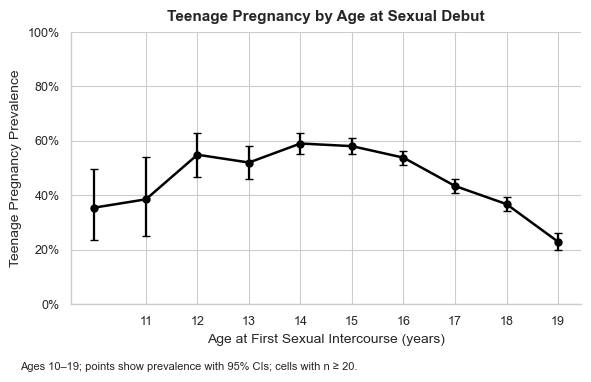

In [12]:
# Group by sex age year
gb = (cc.groupby('sex_age', as_index=False)
        .agg(n=('ado_preg', 'size'),
             cases=('ado_preg', 'sum')))

# Keep stable cells
cc_fig = cc[cc['sex_age'].between(10, 19)].copy()

gb = (cc_fig.groupby('sex_age', as_index=False)
      .agg(n=('ado_preg','size'),
           cases=('ado_preg','sum')))

gb = gb[gb['n'] >= MIN_N].copy()

print("cc total:", len(cc))
print("cc_fig (debut 10–19):", len(cc_fig))
print("gb sum n:", gb['n'].sum())


# Prevalence + Wilson 95% CI
gb['prev'] = gb['cases'] / gb['n']
ci = gb.apply(lambda r: pd.Series(wilson_ci(int(r['cases']), int(r['n'])),
                                  index=['ci_low','ci_high']), axis=1)
gb = pd.concat([gb, ci], axis=1)

# Percent formats
gb['prev_pct'] = (100 * gb['prev']).round(1)
gb['ci_low_pct'] = (100 * gb['ci_low']).round(1)
gb['ci_high_pct'] = (100 * gb['ci_high']).round(1)

# Sort & endpoints
gb = gb.sort_values('sex_age').reset_index(drop=True)
first_row = gb.iloc[0]
last_row  = gb.iloc[-1]


print("\nPrevalence of teenage pregnancy by age at first sex:")
print(gb[['sex_age','n','cases','prev_pct','ci_low_pct','ci_high_pct']].to_string(index=False))
print(f"Total number of cases: {cc.sex_age.shape}")
print("\nTrend endpoints:")
print(f"From {first_row['prev_pct']:.1f}% (95% CI {first_row['ci_low_pct']:.1f}, {first_row['ci_high_pct']:.1f}) "
      f"at age {int(first_row['sex_age'])}, "
      f"to {last_row['prev_pct']:.1f}% (95% CI {last_row['ci_low_pct']:.1f}, {last_row['ci_high_pct']:.1f}) "
      f"at age {int(last_row['sex_age'])}.")

# ---------------------------------------
# PLOT
# ---------------------------------------
y = gb['prev'].to_numpy()
yerr = np.vstack([y - gb['ci_low'].to_numpy(),
                  gb['ci_high'].to_numpy() - y])
x = gb['sex_age'].to_numpy()

plt.figure(figsize=FIGSIZE)
ax = plt.gca()

ax.errorbar(x, y, yerr=yerr, fmt='o-', linewidth=LINEWIDTH, markersize=MARKERSIZE,
            capsize=CAPSIZE, elinewidth=LINEWIDTH*0.9, ecolor='black', color='black')

ax.set_title("Teenage Pregnancy by Age at Sexual Debut", fontsize=FONTSIZE+1, weight='bold', pad=8)
ax.set_xlabel("Age at First Sexual Intercourse (years)", fontsize=FONTSIZE)
ax.set_ylabel("Teenage Pregnancy Prevalence", fontsize=FONTSIZE)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_ylim(0.0, 1.0)
ax.set_xticks(np.arange(11, 20, 1))
ax.tick_params(labelsize=FONTSIZE-1)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

note = f"Ages 10–19; points show prevalence with 95% CIs; cells with n ≥ {MIN_N}."
ax.text(-0.1, -0.25, note, transform=ax.transAxes, fontsize=FONTSIZE-2, va='bottom')

plt.tight_layout()
plt.savefig("./results/teen_preg_by_debut_age.png", dpi=400, bbox_inches="tight")
plt.show()

## Time to pregnancy after sexual debut

The first figure shows the mean years from debut to first pregnancy by age at sexual debut (10–19). A shorter interval at later debut ages does not imply later debut causes faster pregnancy. It mainly reflects exposure time and design truncation (teen window closes at ~20), not a biological acceleration.

The dumbbell figure shows for each debut age, the median age at first pregnancy clusters within the overall IQR of pregnancy ages (16–19). This shows that, regardless of when sexual debut occurs, first pregnancies tend to occur in mid–late adolescence.

Note that ages 18–19 have mechanically short intervals when restricting to teen pregnancies (right-truncation).

Social factors (e.g., marriage/cohabitation, schooling completion) may also align pregnancies to 16–19, but we treat these as plausible correlates, not causal claims.

SAMPLE COUNTS
* Cases (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, age ≥20): 1,040

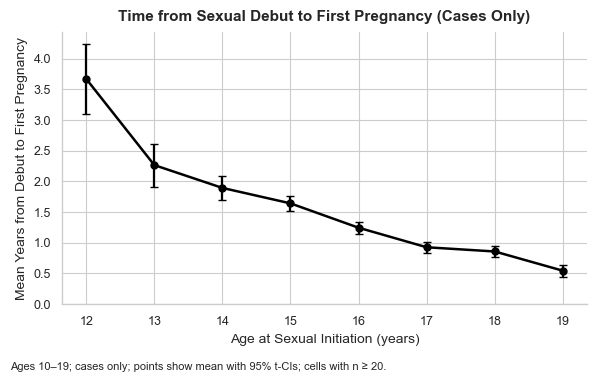

 sex_age_year   n  mean  ci_low  ci_high
           12  88  3.67    3.09     4.25
           13 136  2.26    1.91     2.62
           14 373  1.89    1.70     2.08
           15 654  1.64    1.51     1.77
           16 788  1.24    1.14     1.34
           17 733  0.92    0.84     1.01
           18 681  0.86    0.77     0.95
           19 258  0.54    0.45     0.64


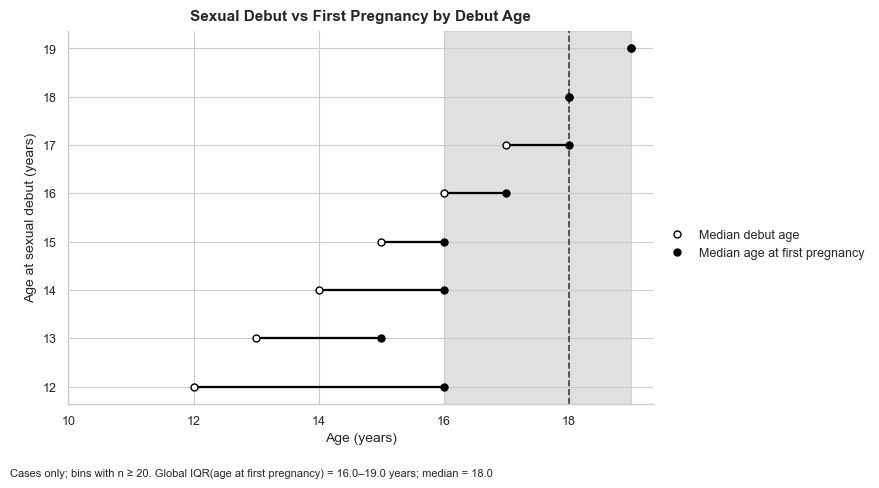

 sex_age_year   n  debut_med  preg_med
           12  88      12.00     16.00
           13 136      13.00     15.00
           14 373      14.00     16.00
           15 654      15.00     16.00
           16 788      16.00     17.00
           17 733      17.00     18.00
           18 681      18.00     18.00
           19 258      19.00     19.00


In [13]:
c = cc.copy()

# Keep only rows with valid debut age
c['sex_age'] = pd.to_numeric(c['sex_age'], errors='coerce')
c = c[np.isfinite(c['sex_age'])].copy()

# If time_to_preg needs pregnancy age, require age_preg too
c['age_preg'] = pd.to_numeric(c['age_preg'], errors='coerce')
c = c[np.isfinite(c['age_preg'])].copy()

# Now safe
c['sex_age_year'] = c['sex_age'].round().astype(int)
c['time_to_preg'] = c['age_preg'] - c['sex_age']


# ---------------------------------------
# PLOT : mean_time_to_preg_by_debut_age_errorbars
# ---------------------------------------

# Per-age summary with t-based 95% CI
summary = (
    c.groupby('sex_age_year')['time_to_preg']
         .agg(n='count',
              mean='mean',
              sd=lambda x: x.std(ddof=1))
         .reset_index()
)

summary['se'] = summary['sd'] / np.sqrt(summary['n'])
summary['tcrit'] = 1.96
summary['ci_low']  = summary['mean'] - summary['tcrit'] * summary['se']
summary['ci_high'] = summary['mean'] + summary['tcrit'] * summary['se']

plot_df = summary[(summary['sex_age_year'] >= 10) & (summary['sex_age_year'] <= 19) & (summary['n'] >= MIN_N)] \
          .sort_values('sex_age_year').copy()

x = plot_df['sex_age_year'].to_numpy()
y = plot_df['mean'].to_numpy()
yerr = np.vstack([y - plot_df['ci_low'].to_numpy(),
                  plot_df['ci_high'].to_numpy() - y])

plt.figure(figsize=FIGSIZE)
ax = plt.gca()

# Error bar
ax.errorbar(
    x, y, yerr=yerr,
    fmt='o-', color='black', ecolor='black',
    linewidth=LINEWIDTH, markersize=MARKERSIZE,
    capsize=CAPSIZE, elinewidth=LINEWIDTH*0.9
)

# Label
ax.set_xlabel("Age at Sexual Initiation (years)", fontsize=FONTSIZE)
ax.set_ylabel("Mean Years from Debut to First Pregnancy", fontsize=FONTSIZE)
ax.set_xticks(np.arange(12, 20, 1))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(labelsize=FONTSIZE-1)
ax.set_ylim(bottom=0)  # start at 0 to avoid exaggeration

# Spine
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

# Note
note = f"Ages 10–19; cases only; points show mean with 95% t-CIs; cells with n ≥ {MIN_N}."
ax.text(-0.1, -0.25, note, transform=ax.transAxes, fontsize=FONTSIZE-2, va='bottom')

# Show
ax.set_title("Time from Sexual Debut to First Pregnancy (Cases Only)", fontsize=FONTSIZE+1, weight='bold', pad=8)
plt.tight_layout()
plt.savefig("./results/mean_time_to_preg_by_debut_age_errorbars.png", dpi=400)
plt.show()

# Table shown in the figure
print(plot_df[['sex_age_year','n','mean','ci_low','ci_high']].round(2).to_string(index=False))

# ---------------------------------------
# PLOT : dumbbell_debut_vs_preg_GLOBAL_IQR
# ---------------------------------------

# Per-age medians for debut and pregnancy
summary = (
    c.groupby('sex_age_year')
         .agg(n=('age_preg','size'),
              debut_med=('sex_age','median'),
              preg_med =('age_preg','median'))
         .reset_index()
         .sort_values('sex_age_year')
)

# Keep stable bins
plot_df = summary[(summary['sex_age_year'].between(10,19)) & (summary['n'] >= MIN_N)].copy()
ypos = np.arange(len(plot_df))

# GLOBAL IQR band on the same population
ages_to_keep = set(plot_df['sex_age_year'].tolist())
used_rows = c[c['sex_age_year'].isin(ages_to_keep)].copy()

q1 = used_rows['age_preg'].quantile(0.25)
q3 = used_rows['age_preg'].quantile(0.75)
med_all = used_rows['age_preg'].median()

plt.figure(figsize=(9.0, 5.0))
ax = plt.gca()

for yi, a, b in zip(ypos, plot_df['debut_med'], plot_df['preg_med']):
    ax.hlines(yi, xmin=a, xmax=b, color='black', linewidth=LINEWIDTH*0.9)
ax.plot(plot_df['debut_med'], ypos, 'o', mfc='white', mec='black', ms=MARKERSIZE, label='Median debut age')
ax.plot(plot_df['preg_med'],  ypos, 'o', mfc='black',  mec='black', ms=MARKERSIZE, label='Median age at first pregnancy')

# Axes
ax.axvspan(q1, q3, alpha=0.12, color='black', zorder=0)
ax.axvline(med_all, linestyle='--', linewidth=1.2, color='black', alpha=0.7)

# Labels
ax.set_title("Sexual Debut vs First Pregnancy by Debut Age", fontsize=FONTSIZE+1, weight='bold', pad=8)
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df['sex_age_year'].astype(int))
ax.set_ylabel("Age at sexual debut (years)", fontsize=FONTSIZE)
ax.set_xlabel("Age (years)", fontsize=FONTSIZE)
ax.set_xlim(left=10)
ax.tick_params(labelsize=FONTSIZE-1)

# Spine
for spine in ("top","right"):
    ax.spines[spine].set_visible(False)

# Legend + note
band_txt = f"Global IQR(age at first pregnancy) = {q1:.1f}–{q3:.1f} years; median = {med_all:.1f}"
ax.legend(frameon=False, fontsize=FONTSIZE-1, bbox_to_anchor=(1, 0.5))
ax.text(-0.1, -0.2,
        f"Cases only; bins with n ≥ {MIN_N}. {band_txt}" + (" (teen pregnancies only)" if TEEN_ONLY else ""),
        transform=ax.transAxes, fontsize=FONTSIZE-2, va='bottom')

# Show
plt.tight_layout()
plt.savefig("./results/dumbbell_debut_vs_preg_GLOBAL_IQR.png", dpi=400)
plt.show()

# Table shown in the figure
print(plot_df[['sex_age_year','n','debut_med', 'preg_med']].round(2).to_string(index=False))

## KM-based cumulative incidence by debut age

KM needs the full risk set of initiators and then censors those who don’t have a teen pregnancy by the end of follow-up (age 20 here).<br>
So here we include all girls that have initiated even if they are still in the risk period. Those who are past the risk period are censored up to 20 years.

SAMPLE COUNTS
* Cases    (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, irrespective of current age): 2,136

Within 1 year: 34.4% (95% CI 33.3, 35.6)
Within 2 years: 44.0% (95% CI 42.8, 45.3)
 sex_age_year    n  inc_1y_pct  inc_1y_lo  inc_1y_hi  inc_2y_pct  inc_2y_lo  inc_2y_hi
           10   48        0.00       0.00       0.00        2.20       0.30      14.70
           11   39       12.80       5.50      28.10       15.50       7.30      31.40
           12  144       18.70      13.10      26.20       25.90      19.30      34.20
           13  251       24.90      20.00      30.90       35.80      29.90      42.50
           14  600       30.50      27.00      34.50       46.00      41.90      50.30
           15 1051       34.90      32.10      37.90       49.10      46.00      52.30
           16 1358       38.60      36.00      41.30       51.60      48.90      54.50
           17 1495       38.70      36.30      41.30       47.40      44.70      50.20
           18 1421       38.50      36.00      41.20       38.50      36.00      41.20
           19  667       23.10      20.10      

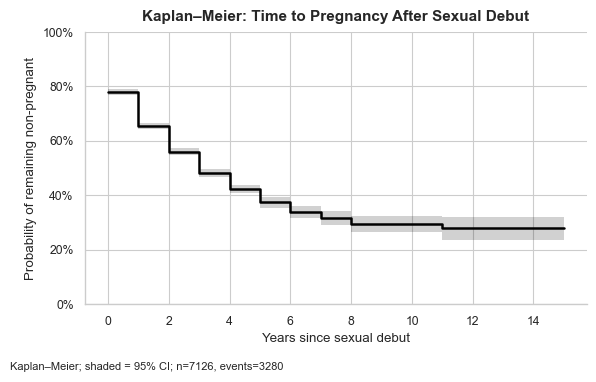

In [14]:
# Keep initiators in teen window only
km = df_raw[df_raw['sex_age'].le(19)].copy()
km['sex_age_year'] = np.floor(km['sex_age']).astype(int)

# Event time (if teen pregnancy) or censoring time (to min(20, interview age))
# 1) Event: teen pregnancy
km['event']   = (km['ado_preg'] == 1).astype(int)
km['t_event'] = km['age_preg'] - km['sex_age']

# 2) Censoring: no teen pregnancy by interview or by 20
#    If event==0, use min(20, age_completed) - sex_age
km['t_cens'] = np.minimum(20.0, km['age_completed']) - km['sex_age']

# Final analysis time = event time if event==1 else censor time
km['duration'] = np.where(km['event'].eq(1), km['t_event'], km['t_cens'])

# Guardrails: drop negatives / missing durations
km = km[np.isfinite(km['duration']) & (km['duration'] >= 0)].copy()

# Fit overall KM
kmf_overall = KaplanMeierFitter()
kmf_overall.fit(km['duration'], event_observed=km['event'])

inc1, lo1, hi1 = km_incidence_at(kmf_overall, 1)
inc2, lo2, hi2 = km_incidence_at(kmf_overall, 2)
print(f"Within 1 year: {inc1*100:.1f}% (95% CI {lo1*100:.1f}, {hi1*100:.1f})")
print(f"Within 2 years: {inc2*100:.1f}% (95% CI {lo2*100:.1f}, {hi2*100:.1f})")

# Per debut-age
rows = []
for age, g in km.groupby('sex_age_year'):
    if 10 <= age <= 19 and len(g) >= 20:  # stability rule
        kmf = KaplanMeierFitter().fit(g['duration'], event_observed=g['event'])
        a1, a1_lo, a1_hi = km_incidence_at(kmf, 1)
        a2, a2_lo, a2_hi = km_incidence_at(kmf, 2)
        rows.append(dict(
            sex_age_year=age, n=len(g),
            inc_1y_pct=round(a1*100,1), inc_1y_lo=round(a1_lo*100,1), inc_1y_hi=round(a1_hi*100,1),
            inc_2y_pct=round(a2*100,1), inc_2y_lo=round(a2_lo*100,1), inc_2y_hi=round(a2_hi*100,1),
        ))
tab_teen = pd.DataFrame(rows).sort_values('sex_age_year')
print(tab_teen.to_string(index=False))

# Check survival at 1 & 2 directly
print("Overall survival at 1 year:", float(kmf_overall.survival_function_at_times(1).values[0]))
print("Overall survival at 2 years:", float(kmf_overall.survival_function_at_times(2).values[0]))

# ---------------------------------------
# PLOT : km_time_to_preg
# ---------------------------------------
sf = kmf_overall.survival_function_
ci = kmf_overall.confidence_interval_

sf_col  = sf.columns[0]
low_col = [c for c in ci.columns if 'lower' in c.lower()][0]
high_col= [c for c in ci.columns if 'upper' in c.lower()][0]

# Align CI to SF timeline and convert to arrays
t  = sf.index.values.astype(float)
lo = ci[low_col].reindex(sf.index, method='pad').values.astype(float)
hi = ci[high_col].reindex(sf.index, method='pad').values.astype(float)
s  = sf[sf_col].values.astype(float)

# Remove any NaNs that could break fill_between
m = np.isfinite(t) & np.isfinite(lo) & np.isfinite(hi) & np.isfinite(s)
t, lo, hi, s = t[m], lo[m], hi[m], s[m]

fig, ax = plt.subplots(figsize=(6,4))

# 95% CI shaded band (behind the step)
ax.fill_between(t, lo, hi, step='post', alpha=0.18, color='black', linewidth=0, zorder=1)

# KM step line
ax.step(t, s, where='post', linewidth=1.8, color='black', zorder=2)

ax.set_title("Kaplan–Meier: Time to Pregnancy After Sexual Debut", fontsize=FONTSIZE+1, weight='bold', pad=8)
ax.set_xlabel("Years since sexual debut")
ax.set_ylabel("Probability of remaining non-pregnant")
ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
ax.set_ylim(0, 1)
for spine in ("top","right"): ax.spines[spine].set_visible(False)
ax.text(-0.15, -0.25, f"Kaplan–Meier; shaded = 95% CI; n={len(km)}, events={int(km['event'].sum())}",
        transform=ax.transAxes, fontsize=8, va='bottom')

plt.tight_layout()
plt.savefig("./results/km_time_to_preg.png", dpi=400, bbox_inches="tight")
plt.show()

## Logistic Regression

SAMPLE COUNTS
* Cases (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, age ≥20): 1,040
* Total after dropping NAs : 2,768

*adjusting for marriage*
It’s very likely on the causal pathway that earlier debut → earlier/greater chance of marriage → higher pregnancy risk. Adjusting for it would attenuate the effect you want to estimate.

RESULTS<br>
Per-year delay: aOR = 0.61 p<0.001 -> After accounting for partner type and willingness/avoidance indicators, later sexual debut remains protective—about 39% lower odds per year.

In [15]:
# Keep initiators with complete data on these covariates
dfm = cc[['ado_preg','sex_age','will_sex_binary','do_anything_binary','person_sex_group']].dropna().copy()

# Dummies for partner at first sex (baseline = first category alphabetically)
dfm['person_sex_group'] = pd.Categorical(dfm['person_sex_group'])
partner_dummies = pd.get_dummies(dfm['person_sex_group'], prefix='partner', drop_first=True, dtype=float)

# Outcome & predictors
y = dfm['ado_preg'].astype(int)
X = pd.concat(
    [dfm[['sex_age','will_sex_binary','do_anything_binary']].astype(float), partner_dummies],
    axis=1
)
X = sm.add_constant(X, has_constant='add')

# Fit
m = sm.Logit(y, X).fit(disp=False)
# Robust SEs
try:
    m = m.get_robustcov_results(cov_type='HC1')
except Exception:
    pass

print(m.summary())

b, (lo, hi) = m.params['sex_age'], m.conf_int().loc['sex_age']
print(f"Age of initiation (+1): aOR {np.exp(b):.3f} (95% CI {np.exp(lo):.3f}, {np.exp(hi):.3f})")
print("Model N:", len(dfm))
print("Events (ado_preg==1):", int(dfm['ado_preg'].sum()))
print("Controls:", int((dfm['ado_preg']==0).sum()))
print("Partner distribution:\n", dfm['person_sex_group'].value_counts(dropna=False))


                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                 7412
Model:                          Logit   Df Residuals:                     7406
Method:                           MLE   Df Model:                            5
Date:                Mon, 09 Feb 2026   Pseudo R-squ.:                  0.1044
Time:                        10:01:24   Log-Likelihood:                -4522.9
converged:                       True   LL-Null:                       -5050.2
Covariance Type:            nonrobust   LLR p-value:                9.427e-226
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.9084      0.222     17.641      0.000       3.474       4.343
sex_age               -0.2543      0.013    -19.471      0.000      -0.280      -0.229
will_sex_binary     

# Teenage Pregnancy and School Dropout

**Does teenage pregnancy increase school dropout risk?**
* Descriptive: What is the prevalence of teen pregnancy by schooling status (ages 10–19 at interview)?
* Modelling: What is the association between schooling exposure and teen pregnancy risk during adolescence, adjusting for time-at-risk and marriage timing?

## Descriptive snapshot (prevalence by current schooling status)

**What is the prevalence of teen pregnancy by schooling status, among girls aged 10 - 19 at the time of the interview?**

SAMPLE COUNTS
* Cases (age completed ≤19 & pregnant ≤19): 594
* Controls (age completed ≤19 & NOT pregnant ≤19): 4,127

*Note.* This is associational and partly reflects selection (older teens are more likely to be out of school and also to have had time to become pregnant).

*Note.* Since schooling is measured at interview (not at the time of pregnancy), the safest way for this cases-only table is to combine “in_school” + “completed_USE” into a single bucket (call it “in-school/completed”), so we don’t imply that girls who later finished school were out of school at the time of pregnancy.

In [16]:
d = df_raw.copy()

# Universe: girls aged 10–19 at interview
d['age_completed'] = pd.to_numeric(d['age_completed'], errors='coerce')
d = d[d['age_completed'].between(10, 19)].copy()

# Outcome
d['ado_preg'] = pd.to_numeric(d['ado_preg'], errors='coerce').fillna(0).astype(int)

# Schooling status (use your patched 3-level if available)
VALID_STATUS = ['in_school', 'completed_lower_secondary', 'dropped_out']

# Option A (recommended): keep unknown, then decide per-table
d['school_status3'] = d['school_complete3_lbl']
d.loc[~d['school_status3'].isin(VALID_STATUS), 'school_status3'] = 'unknown_status'

# Cases/controls for this cross-section
cases    = d[d['ado_preg'].eq(1)].copy()
controls = d[d['ado_preg'].eq(0)].copy()
cc = pd.concat([cases, controls], axis=0)
cc['case'] = cc['ado_preg']

print("SAMPLE COUNTS (10–19 at interview)")
print("Total:", len(d))
print("Cases (teen preg):", len(cases))
print("Controls:", len(controls))
print("\nSchool status distribution (incl unknown):")
print(d['school_status3'].value_counts(dropna=False))


SAMPLE COUNTS (10–19 at interview)
Total: 6379
Cases (teen preg): 1257
Controls: 5122

School status distribution (incl unknown):
school_status3
in_school                    3320
dropped_out                  2213
completed_lower_secondary     693
unknown_status                153
Name: count, dtype: int64


In [17]:
# ===============================
# TABLE A — PREVALENCE & 95% CI BY SCHOOL STATUS (within cc)
# ===============================
tab_prev = (cc.groupby('school_complete3_lbl', as_index=False)
              .agg(n=('ado_preg','size'),
                   cases=('ado_preg','sum'))
              .sort_values('school_complete3_lbl'))

tab_prev = add_prev_ci(tab_prev, num='cases', den='n')  # your function

print("\nTeen pregnancy prevalence by schooling status (≤19 cohort):")
tab_prev[['school_complete3_lbl','n','cases','prev_pct','ci_low_pct','ci_high_pct']].to_string(index=False)
tab_prev


Teen pregnancy prevalence by schooling status (≤19 cohort):


,school_complete3_lbl,n,cases,ci_low,ci_high,prev_pct,ci_low_pct,ci_high_pct
0,completed_lower_secondary,693,278,0.37,0.44,40.10,36.50,43.80
1,dropped_out,2213,861,0.37,0.41,38.90,36.90,41.00
2,in_school,3320,65,0.02,0.02,2.00,1.50,2.50


In [18]:
# ===============================
# TABLE B — BREAKDOWN OF SCHOOL STATUS BY TEEN-PREG OUTCOME (row-wise %)
# ===============================
# Labels for rows
cc['ado_preg_label'] = cc['ado_preg'].map({0: 'No teen pregnancy', 1: 'Teen pregnancy'})

status_order = [s for s in VALID_STATUS if s in cc['school_complete3_lbl'].unique()]

cnt = (pd.crosstab(cc['ado_preg_label'], cc['school_complete3_lbl'])
         .reindex(index=['No teen pregnancy','Teen pregnancy'])
         .reindex(columns=status_order, fill_value=0)
         .astype('Int64'))

row_tot = cnt.sum(axis=1).replace(0, np.nan)
pct = (cnt.div(row_tot, axis=0) * 100).round(1)

table_breakdown = pd.concat(
    [cnt.add_suffix(' (n)'), pct.add_suffix(' (%)')],
    axis=1
)

print("\nSchooling distribution by teen-pregnancy status (row-wise %):")
table_breakdown.to_string()
table_breakdown


Schooling distribution by teen-pregnancy status (row-wise %):


school_complete3_lbl,in_school (n),completed_lower_secondary (n),dropped_out (n),in_school (%),completed_lower_secondary (%),dropped_out (%)
ado_preg_label,,,,,,
No teen pregnancy,3255,415,1352,64.80,8.30,26.90
Teen pregnancy,65,278,861,5.40,23.10,71.50


**Cases-only: Age of pregnancy × schooling status for girls 10 - 19 at interview**

In [19]:
# ===============================
# TABLE C — CASES ONLY: AGE AT FIRST PREGNANCY × SCHOOL STATUS (row-wise %)
# ===============================
cases = cases.copy()
cases = cases[cases['age_preg'].notna()]  # ensure age_preg exists
cases['age_preg_year'] = cases['age_preg'].astype(int)

ages = pd.Index(range(10, 20), name='age_preg_year')

cnt_age = (cases.groupby(['age_preg_year', 'school_complete3_lbl'])
                 .size()
                 .unstack('school_complete3_lbl')
                 .reindex(ages, fill_value=0))

# ensure the 3 columns exist and are ordered
for col in VALID_STATUS:
    if col not in cnt_age.columns:
        cnt_age[col] = 0
cnt_age = cnt_age[VALID_STATUS].astype('Int64')

# totals + row-wise %
cnt_age['total (n)'] = cnt_age.sum(axis=1).astype('Int64')
den_age = cnt_age['total (n)'].astype('float64').replace(0, np.nan)
pct_age = (cnt_age[VALID_STATUS].astype('float64').div(den_age, axis=0) * 100).round(1).fillna(0.0)

table_age = pd.DataFrame({
    'in-school (n)':                 cnt_age['in_school'],
    'in-school (%)':                 pct_age['in_school'],
    'completed lower secondary (n)': cnt_age['completed_lower_secondary'],
    'completed lower secondary (%)': pct_age['completed_lower_secondary'],
    'dropped-out (n)':               cnt_age['dropped_out'],
    'dropped-out (%)':               pct_age['dropped_out'],
    'total (n)':                     cnt_age['total (n)'],
    'total (%)':                     100.0,
})

print("\nColumn totals (cases only):")
print(f"Total in-school: {int(table_age['in-school (n)'].sum())}")
print(f"Completed lower secondary: {int(table_age['completed lower secondary (n)'].sum())}")
print(f"Total dropped-out: {int(table_age['dropped-out (n)'].sum())}")
print(f"Total: {int(table_age['total (n)'].sum())}")

print("\nCASES ONLY — Exact age at first pregnancy × School status (row-wise %):")
table_age.to_string()
table_age


Column totals (cases only):
Total in-school: 65
Completed lower secondary: 278
Total dropped-out: 861
Total: 1204

CASES ONLY — Exact age at first pregnancy × School status (row-wise %):


,in-school (n),in-school (%),completed lower secondary (n),completed lower secondary (%),dropped-out (n),dropped-out (%),total (n),total (%)
age_preg_year,,,,,,,,
10,0,0.00,0,0.00,0,0.00,0,100.00
11,<NA>,0.00,<NA>,0.00,2,100.00,2,100.00
12,<NA>,0.00,<NA>,0.00,7,100.00,7,100.00
13,<NA>,0.00,1,4.00,24,96.00,25,100.00
14,5,6.90,4,5.60,63,87.50,72,100.00
15,5,3.30,22,14.70,123,82.00,150,100.00
16,10,3.30,61,20.30,229,76.30,300,100.00
17,23,6.70,86,25.10,234,68.20,343,100.00
18,18,7.50,77,32.20,144,60.30,239,100.00


In [20]:
d = df_raw.copy()

VALID_STATUS = ['in_school', 'completed_lower_secondary', 'dropped_out']

# Start with what you already have
d['school_status3'] = d['school_complete3_lbl']

# Flag missing
miss = d['school_status3'].isna()

# Fallback from years_school (based on your mapping: S4 completion = 11 years)
d.loc[miss & (d['years_school'] == 0), 'school_status3'] = 'dropped_out'
d.loc[miss & (d['years_school'] >= 11), 'school_status3'] = 'completed_lower_secondary'

# For the rest (years_school 1–10), we can't know in_school vs dropped_out without enrollment
# Put them in an explicit category
d.loc[miss & d['school_status3'].isna(), 'school_status3'] = 'unknown_status'

# Quick audit among CASES (initiated ≤19 & pregnant ≤19)
cases = d[(d['sex_age'] <= 19) & (d['ado_preg'] == 1)].copy()

print("Before patch (original):")
print(cases['school_complete3_lbl'].value_counts(dropna=False))

print("\nAfter patch (school_status3):")
print(cases['school_status3'].value_counts(dropna=False))

# How many got resolved vs remain unknown?
resolved = ((cases['school_complete3_lbl'].isna()) & (cases['school_status3'] != 'unknown_status')).sum()
still_unk = ((cases['school_complete3_lbl'].isna()) & (cases['school_status3'] == 'unknown_status')).sum()
print(f"\nPatched from missing -> known via years_school: {resolved}")
print(f"Still unknown (years_school 1–10): {still_unk}")


Before patch (original):
school_complete3_lbl
dropped_out                  2098
completed_lower_secondary     847
NaN                           168
in_school                     167
Name: count, dtype: int64

After patch (school_status3):
school_status3
dropped_out                  2222
completed_lower_secondary     865
in_school                     167
unknown_status                 26
Name: count, dtype: int64

Patched from missing -> known via years_school: 142
Still unknown (years_school 1–10): 26


**Cases-only: By education pool (≤UPE / USE / USE+) × schooling status for girls 10 - 19 at interview**

In [21]:
pool_map = {
    'less_than_UPE': '≤UPE',
    'UPE':            'UPE',
    'USE':            'USE',
    'higher_than_USE':'USE+',
    'Unknown':        'Unknown'
}
edu_order = ['≤UPE', 'UPE', 'USE', 'USE+', 'Unknown']

status_var   = 'school_status3'   # patched
VALID_STATUS = ['in_school', 'completed_lower_secondary', 'dropped_out']

cases2 = cases.copy()

# (A) Restrict to 10–19 at interview for the schooling-status section
cases2 = cases2[cases2['age_completed'].between(10, 19)].copy()

# (B) Build edu_pool from edu_bucket_highest first
edu_pool = cases2['edu_bucket_highest'].map(pool_map)

# (C) Fill missing edu_pool using years_school, but treat 0 as Unknown (NOT ≤UPE)
ys = pd.to_numeric(cases2['years_school'], errors='coerce')

fill_from_ys = np.select(
    [
        ys.isna(),
        ys.eq(0),
        ys.between(1, 7),
        ys.between(8, 11),
        ys.ge(12),
    ],
    ['Unknown', 'Unknown', 'UPE', 'USE', 'USE+'],
    default='Unknown'
)

edu_pool = edu_pool.fillna(pd.Series(fill_from_ys, index=cases2.index))
cases2['edu_pool'] = pd.Categorical(edu_pool, categories=edu_order, ordered=True)

# (D) Keep only known schooling status
cases2 = cases2[cases2[status_var].isin(VALID_STATUS)].copy()

# (E) Crosstab
cnt_edu = (cases2.groupby(['edu_pool', status_var])
                .size()
                .unstack(status_var)
                .reindex(index=edu_order, fill_value=0)
                .reindex(columns=VALID_STATUS, fill_value=0))

cnt_edu['total (n)'] = cnt_edu.sum(axis=1)

den = cnt_edu['total (n)'].replace(0, np.nan)
pct = (cnt_edu[VALID_STATUS].div(den, axis=0) * 100).round(1)

table_edu = pd.DataFrame({
    'in-school (n)':                 cnt_edu['in_school'],
    'in-school (%)':                 pct['in_school'],
    'completed lower secondary (n)': cnt_edu['completed_lower_secondary'],
    'completed lower secondary (%)': pct['completed_lower_secondary'],
    'dropped-out (n)':               cnt_edu['dropped_out'],
    'dropped-out (%)':               pct['dropped_out'],
    'total (n)':                     cnt_edu['total (n)'],
    'total (%)':                     100.0,
})

# Drop zero rows for reporting
table_edu = table_edu[table_edu['total (n)'] > 0]

table_edu


,in-school (n),in-school (%),completed lower secondary (n),completed lower secondary (%),dropped-out (n),dropped-out (%),total (n),total (%)
edu_pool,,,,,,,,
≤UPE,1,50.00,0,0.00,1,50.00,2,100.00
UPE,17,1.90,0,0.00,860,98.10,877,100.00
USE,4,1.40,273,98.60,0,0.00,277,100.00
USE+,12,50.00,12,50.00,0,0.00,24,100.00
Unknown,31,47.70,0,0.00,34,52.30,65,100.00


## Logistic Regression

**Estimate the association between schooling exposure and teen pregnancy risk during adolescence, adjusting for time-at-risk and marriage timing.**

SAMPLE COUNTS
* Cases (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, age ≥20): 1,040 -> outside of risk window
* Total after dropping NAs : 2,192

*Deriving “years of schooling”*

When a direct count of years completed (years_school) was available, we used it as reported (after coercing to numeric and treating non-numeric entries as missing).
If years_school was unavailable, we imputed an approximate years-of-schooling measure from the respondent’s highest level completed (level_scol_recode) using the following mapping, consistent with the Ugandan system and our analytic need to place respondents on a single continuous scale:

* level_scol_recode ∈ {2, 3} → 7 years (completed primary/UPE)
* level_scol_recode ∈ {4, 5} → 11 years (completed lower secondary / O-Level, i.e., USE)
* level_scol_recode = 6 → 13 years (completed upper secondary / A-Level)
* level_scol_recode ∈ {7, 8, 9} → 14 years (any tertiary or higher)

All other or invalid level_scol_recode values were left missing. This produces a conservative, monotonic approximation that preserves ordering across schooling milestones while minimizing arbitrary precision beyond level boundaries.

*Covariates*

Not controlling for willingness, partner type, or contraception in your primary schooling model. These are very likely post-exposure mediators (schooling → later debut / different partners / more prevention → lower pregnancy risk). Adjusting for them would bias the schooling effect toward the null.

In [22]:
# --- prep & filtering ---
d = df_raw.copy()

cases = d[(d['sex_age'] <= 19) & (d['ado_preg'] == 1)]
controls = d[(d['sex_age'] <= 19) & (d['ado_preg'] == 0) & (d['age_completed'] >= 20)]

cc = pd.concat([cases, controls], axis=0).copy()

# --- outcome ---
cc['ado_preg'] = cc['ado_preg'].astype(int)

# --- schooling ---


# --- risk time (teen exposure) ---
risk_end = np.minimum(19.0, cc['age_completed'])
cc['risk_time'] = np.where(cc['sex_age'].notna(),
                           np.clip(risk_end - cc['sex_age'], 0, None),
                           0.0)

# --- center covariates ---
cc['years_school_c']   = cc['years_school']   - cc['years_school'].mean()
cc['age_completed_c']  = cc['age_completed']  - cc['age_completed'].mean()

dm = cc[['ado_preg','years_school_c','risk_time','age_completed_c','married_by19']].dropna()
y  = dm['ado_preg'].astype(int)
X  = sm.add_constant(dm.drop(columns=['ado_preg']).astype(float))

m = sm.Logit(y, X).fit(disp=False)
print(m.summary())

b, (lo, hi) = m.params['years_school_c'], m.conf_int().loc['years_school_c']
print(f"Years of schooling (+1): aOR {np.exp(b):.3f} (95% CI {np.exp(lo):.3f}, {np.exp(hi):.3f})")

                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                 2965
Model:                          Logit   Df Residuals:                     2960
Method:                           MLE   Df Model:                            4
Date:                Mon, 09 Feb 2026   Pseudo R-squ.:                  0.3717
Time:                        10:01:24   Log-Likelihood:                -1207.1
converged:                       True   LL-Null:                       -1921.1
Covariance Type:            nonrobust   LLR p-value:                5.837e-308
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.3299      0.095     -3.465      0.001      -0.516      -0.143
years_school_c     -0.2307      0.018    -12.930      0.000      -0.266      -0.196
risk_time           0.2349      

# Marriage and Teenage Pregnancy

**What is the effect of early marriage on pregnancy outcomes among teenage girls?**

* Descriptive: Among girls married at m, what % ever had a teen pregnancy (≤19)?
* Modelling: What is the association between teen marriage and teen pregnancy?

## Descriptive snapshot (prevelance by teen marriage)

Given how tight the marriage↔teen-pregnancy link is among those married at age m, the clearer story is the age-t snapshot: compare girls married by age t vs not married by age t, with both groups drawn from girls who were actually observed through age t (i.e., age_completed >= t).

In [35]:
AGES = range(10, 20)

rows = []
for t in AGES:
    # only girls observed through age t
    pool = df_raw[df_raw['age_completed'] >= t].copy()
    if pool.empty:
        continue

    # status at age t
    pool['married_by_t']    = pool['age_marry'].notna() & (pool['age_marry'] <= t)
    pool['ever_preg_by_t']  = (pool['ado_preg'].eq(1) &
                               pool['age_preg'].notna() &
                               (pool['age_preg'] <= t)).astype(int)

    # married-by-t
    g1 = pool[pool['married_by_t']]
    n1 = len(g1); k1 = int(g1['ever_preg_by_t'].sum())
    lo1, hi1 = wilson_ci(k1, n1) if n1 else (float('nan'), float('nan'))

    # not married-by-t
    g0 = pool[~pool['married_by_t']]
    n0 = len(g0); k0 = int(g0['ever_preg_by_t'].sum())
    lo0, hi0 = wilson_ci(k0, n0) if n0 else (float('nan'), float('nan'))

    rows.append({
        'age_t': t,
        'married_n': n1, 'married_prev': k1/n1 if n1 else float('nan'),
        'married_ci_low': lo1, 'married_ci_high': hi1,
        'unmarried_n': n0, 'unmarried_prev': k0/n0 if n0 else float('nan'),
        'unmarried_ci_low': lo0, 'unmarried_ci_high': hi0
    })

tab_by_status_at_age = pd.DataFrame(rows)

# Optional: keep ages where both groups have enough n
MIN_N = 20
stable = tab_by_status_at_age[(tab_by_status_at_age['married_n']   >= MIN_N) &
                              (tab_by_status_at_age['unmarried_n'] >= MIN_N)].copy()

# Example sentence for age 14:
t = 14
r = stable.loc[stable['age_t']==t].squeeze()
print(
    f"At age {t}, the prevalence of having ever been pregnant by that age was "
    f"{r['married_prev']*100:.1f}% (95% CI {r['married_ci_low']*100:.1f}, {r['married_ci_high']*100:.1f}) "
    f"among girls married by age {t}, versus "
    f"{r['unmarried_prev']*100:.1f}% (95% CI {r['unmarried_ci_low']*100:.1f}, {r['unmarried_ci_high']*100:.1f}) "
    f"among those not married by age {t}."
)

t = 19
r = stable.loc[stable['age_t']==t].squeeze()
print(
    f"At age {t}, the prevalence of having ever been pregnant by that age was "
    f"{r['married_prev']*100:.1f}% (95% CI {r['married_ci_low']*100:.1f}, {r['married_ci_high']*100:.1f}) "
    f"among girls married by age {t}, versus "
    f"{r['unmarried_prev']*100:.1f}% (95% CI {r['unmarried_ci_low']*100:.1f}, {r['unmarried_ci_high']*100:.1f}) "
    f"among those not married by age {t}."
)

At age 14, the prevalence of having ever been pregnant by that age was 46.9% (95% CI 36.4, 57.7) among girls married by age 14, versus 1.7% (95% CI 1.5, 2.0) among those not married by age 14.
At age 19, the prevalence of having ever been pregnant by that age was 91.3% (95% CI 89.4, 92.9) among girls married by age 19, versus 30.3% (95% CI 29.1, 31.5) among those not married by age 19.


**Exact age at first pregnancy × marital status at time of pregnancy [cases only]**

In [ ]:
# --- TABLE: Exact age at first pregnancy × marital status at time of pregnancy [cases only] ---
cases = df_raw.copy()
cases    = cases[(cases['ado_preg'] == 1)]

# Marital status at time of first pregnancy:
# "Married before pregnancy" = married and age_marry <= age_preg
cases['married_before_preg'] = cases['age_marry'].notna() & (cases['age_marry'] <= cases['age_preg'])
cases['marital_at_preg'] = np.where(cases['married_before_preg'], 'Married before pregnancy', 'Not married before pregnancy')

# Exact age at first pregnancy (integer 10–19)
cases['age_preg_year'] = np.floor(cases['age_preg']).astype('Int64')

# Count matrix
ages = pd.Index(range(10, 20), name='age_preg_year')
cnt = (
    cases.groupby(['age_preg_year','marital_at_preg'])
         .size()
         .unstack('marital_at_preg')
         .reindex(ages, fill_value=0)
)

# Ensure both columns are present and ordered
cols = ['Married before pregnancy', 'Not married before pregnancy']
for c in cols:
    if c not in cnt.columns: cnt[c] = 0
cnt = cnt[cols].astype('Int64')

# Totals
cnt['Total (n)'] = (cnt[cols].sum(axis=1)).astype('Int64')

# Row-wise % (horizontal: each age sums to 100)
den = cnt['Total (n)'].astype(float).replace(0, np.nan)
pct = (cnt[cols].astype(float).div(den, axis=0) * 100).round(1).fillna(0.0)

# Assemble pretty table
table = pd.DataFrame({
    'Married before pregnancy (n)':         cnt['Married before pregnancy'],
    'Married before pregnancy (%)':         pct['Married before pregnancy'],
    'Not married before pregnancy (n)':     cnt['Not married before pregnancy'],
    'Not married before pregnancy (%)':     pct['Not married before pregnancy'],
    'Total (n)':                            cnt['Total (n)'],
    'Total (%)':                            np.where(cnt['Total (n)']>0, 100.0, 0.0)
}, index=ages)

table.index.name = 'Exact age at first pregnancy'
table.to_string()

# Column totals for headers
n_married = int(cnt['Married before pregnancy'].sum())
n_not     = int(cnt['Not married before pregnancy'].sum())
N_total   = int(cnt['Total (n)'].sum())
print(f"Married before pregnancy (n={n_married}) | Not married before pregnancy (n={n_not}) | Total (N={N_total})")
table

Married before pregnancy (n=873) | Not married before pregnancy (n=2407) | Total (N=3280)


,Married before pregnancy (n),Married before pregnancy (%),Not married before pregnancy (n),Not married before pregnancy (%),Total (n),Total (%)
Exact age at first pregnancy,,,,,,
10,0,0.00,0,0.00,0,0.00
11,<NA>,0.00,4,100.00,4,100.00
12,4,25.00,12,75.00,16,100.00
13,7,14.00,43,86.00,50,100.00
14,25,16.00,131,84.00,156,100.00
15,67,22.00,237,78.00,304,100.00
16,139,23.80,444,76.20,583,100.00
17,198,26.50,549,73.50,747,100.00
18,266,30.80,597,69.20,863,100.00


## KM-based cumulative incidence by marriage age

among girls who marry at ages 10–19, how quickly do pregnancies occur before age 20?

SAMPLE: Girls married in 10–19 (age_marry between 10 and 19) and observed at/after marriage (age_completed >= age_marry) so the “clock start” is observed.

Within 1 year of marriage: 75.0% (95% CI 72.3, 77.7)
Within 2 years of marriage: 82.3% (95% CI 79.5, 84.9)
 marry_age   n  inc_1y_pct  inc_1y_lo  inc_1y_hi  inc_2y_pct  inc_2y_lo  inc_2y_hi
    14.000  42      76.200     62.600     87.700      89.400     77.700     96.500
    15.000 106      72.400     63.500     80.800      78.800     70.300     86.200
    16.000 190      75.100     68.600     81.100      87.200     81.800     91.700
    17.000 265      81.000     76.000     85.600      84.900     80.100     89.100
    18.000 324      76.800     71.900     81.300      76.800     71.900     81.300
    19.000 170      50.000     42.800     57.700      50.000     42.800     57.700


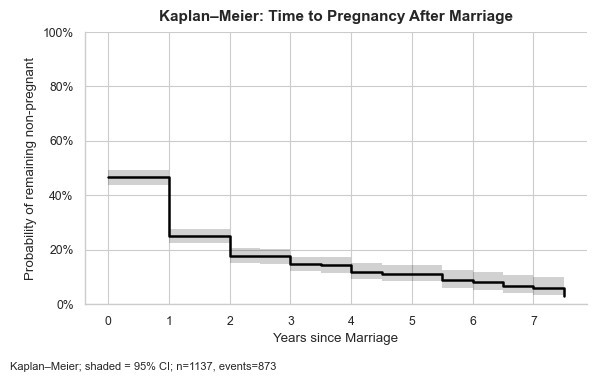

In [37]:
# --- KM: time to 1st pregnancy AFTER marriage, among girls married at 10–19 ---
km = df_raw.copy()

# 1) Keep marriages in teen window and ensure observed at/after marriage
km = km[km['age_marry'].between(10, 19)]
km = km[km['age_completed'].notna() & (km['age_completed'] >= km['age_marry'])]

# 2) Event: teen pregnancy that occurs AFTER marriage (and ≤19)
event_mask = km['age_preg'].notna() & (km['age_preg'] >= km['age_marry']) & (km['age_preg'] <= 19)
km['event']   = event_mask.astype(int)

# 3) Durations
#    - event time if event==1
#    - else censor at min(20, age_completed)
t_event = km['age_preg'] - km['age_marry']
t_cens = np.minimum(19.0, km['age_completed']) - km['age_marry']
km['duration'] = np.where(km['event'].eq(1), t_event, t_cens)

# 4) Guardrails: finite and non-negative time
km = km[np.isfinite(km['duration']) & (km['duration'] >= 0)].copy()

# 5) Overall KM
kmf_overall = KaplanMeierFitter()
kmf_overall.fit(km['duration'], event_observed=km['event'])

inc1, lo1, hi1 = km_incidence_at(kmf_overall, 1)
inc2, lo2, hi2 = km_incidence_at(kmf_overall, 2)
print(f"Within 1 year of marriage: {inc1*100:.1f}% (95% CI {lo1*100:.1f}, {hi1*100:.1f})")
print(f"Within 2 years of marriage: {inc2*100:.1f}% (95% CI {lo2*100:.1f}, {hi2*100:.1f})")

# 6) Stratify by exact age at marriage (stable cells only)
MIN_N = 20
rows = []
for m_age, g in km.groupby('age_marry'):
    if 10 <= m_age <= 19 and len(g) >= MIN_N:
        kmf = KaplanMeierFitter().fit(g['duration'], event_observed=g['event'])
        a1, a1_lo, a1_hi = km_incidence_at(kmf, 1)
        a2, a2_lo, a2_hi = km_incidence_at(kmf, 2)
        rows.append({
            'marry_age': m_age, 'n': len(g),
            'inc_1y_pct': round(a1*100,1), 'inc_1y_lo': round(a1_lo*100,1), 'inc_1y_hi': round(a1_hi*100,1),
            'inc_2y_pct': round(a2*100,1), 'inc_2y_lo': round(a2_lo*100,1), 'inc_2y_hi': round(a2_hi*100,1),
        })
tab_teen = pd.DataFrame(rows).sort_values('marry_age')
print(tab_teen.to_string(index=False))

# ---------------------------------------
# PLOT : km_time_to_preg
# ---------------------------------------
sf = kmf_overall.survival_function_
ci = kmf_overall.confidence_interval_

sf_col  = sf.columns[0]
low_col = [c for c in ci.columns if 'lower' in c.lower()][0]
high_col= [c for c in ci.columns if 'upper' in c.lower()][0]

# Align CI to SF timeline and convert to arrays
t  = sf.index.values.astype(float)
lo = ci[low_col].reindex(sf.index, method='pad').values.astype(float)
hi = ci[high_col].reindex(sf.index, method='pad').values.astype(float)
s  = sf[sf_col].values.astype(float)

# Remove any NaNs that could break fill_between
m = np.isfinite(t) & np.isfinite(lo) & np.isfinite(hi) & np.isfinite(s)
t, lo, hi, s = t[m], lo[m], hi[m], s[m]

fig, ax = plt.subplots(figsize=(6,4))

# 95% CI shaded band (behind the step)
ax.fill_between(t, lo, hi, step='post', alpha=0.18, color='black', linewidth=0, zorder=1)

# KM step line
ax.step(t, s, where='post', linewidth=1.8, color='black', zorder=2)

ax.set_title("Kaplan–Meier: Time to Pregnancy After Marriage", fontsize=FONTSIZE+1, weight='bold', pad=8)
ax.set_xlabel("Years since Marriage")
ax.set_ylabel("Probability of remaining non-pregnant")
ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
ax.set_ylim(0, 1)
for spine in ("top","right"): ax.spines[spine].set_visible(False)
ax.text(-0.15, -0.25, f"Kaplan–Meier; shaded = 95% CI; n={len(km)}, events={int(km['event'].sum())}",
        transform=ax.transAxes, fontsize=8, va='bottom')

plt.tight_layout()
plt.savefig("./results/km_time_to_preg_after_marry.png", dpi=400, bbox_inches="tight")
plt.show()

## Logistic Regression

SAMPLE COUNTS
* Cases (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, age ≥20): 1,040
* Total after dropping NAs : 1,493

RESULTS
Delayed marriage (per +1 year later by 19): aOR 0.343 p<0.001 -> After accounting for age of sexual debut, age completed, partner type and willingness/avoidance indicators, and schooling status, later marriage remains protective—about 66% lower odds per year.

In [36]:
d = df_raw.copy()

cases   = (d['ado_preg'] == 1)
controls = (d['ado_preg'] == 0) & (d['age_completed'] >= 20)

cc = d.loc[cases | controls].copy()

# Exposures/covariates defined up to age 19
# Delayed marriage up to 19: if married <=19, use that age; otherwise 19 (max delay)
cc['marry_age_teen'] = np.where(cc['age_marry'].notna() & (cc['age_marry'] <= 19),
                                cc['age_marry'], 19.0).astype(float)

# Age at sexual debut: if no debut by 19, set to 20 (no exposure within window)
cc['sex_age_teen'] = cc['sex_age'].where(cc['sex_age'].between(10,19), 20.0)

# Behavioral/debut covariates
cc['condom_use_ord_active'] = pd.to_numeric(cc.get('condom_use_ord_active'), errors='coerce')  # ok if missing column

# Partner at first sex dummies
if 'person_sex_group' in cc.columns:
    cc['person_sex_group'] = pd.Categorical(cc['person_sex_group'])
    partner_dum = pd.get_dummies(cc['person_sex_group'], prefix='partner', drop_first=True, dtype=float)
else:
    partner_dum = pd.DataFrame(index=cc.index)

# Schooling status (3-level)
valid_status = ['in_school','completed_lower_secondary','dropped_out']
status = cc['school_complete3_lbl'].where(cc['school_complete3_lbl'].isin(valid_status))
status = pd.Categorical(status, categories=valid_status, ordered=True)
school_dum = pd.get_dummies(status, prefix='school', drop_first=True, dtype=float)  # baseline=in_school

# Assemble design matrix
keep = [
    'ado_preg',
    'marry_age_teen',      # key exposure (per +1 year later by 19)
    'sex_age_teen',        # debut timing (capped)
    'age_completed',       # cohort adjustment
    'will_sex_binary',
    'do_anything_binary',
    'condom_use_ord_active'
]
dm = (cc[keep]
      .join([partner_dum, school_dum])
      .dropna())

y = dm['ado_preg'].astype(int)
X = sm.add_constant(dm.drop(columns=['ado_preg']).astype(float))
m = sm.Logit(y, X).fit(disp=False)
print(m.summary())

# Helper to print ORs
OR, L, H, p = or_ci(m, 'marry_age_teen')
print(f"\nDelayed marriage (per +1 year later by 19): aOR {OR:.3f} (95% CI {L:.3f}, {H:.3f}); p={p:.3g}")

                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                 2291
Model:                          Logit   Df Residuals:                     2280
Method:                           MLE   Df Model:                           10
Date:                Mon, 09 Feb 2026   Pseudo R-squ.:                  0.3403
Time:                        11:00:46   Log-Likelihood:                -1030.5
converged:                       True   LL-Null:                       -1561.9
Covariance Type:            nonrobust   LLR p-value:                5.235e-222
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               36.8998      2.411     15.303      0.000      32.174      41.626
marry_age_teen                      -1.2237      0.119    -10.293

# Condom Use and Teenage Pregnancy

**Does consistent condom use reduce teen pregnancy risk?**

* Descriptive: Is prevelance higher among girls that do not use preventative measures at first sex?
* Modeling: Among all girls who initiated sex: what’s the probability of pregnancy within 1–2 years, and how does it vary by age at debut?

## Descriptive snapshot (prevelance by preventative methods at first sex)

In [27]:
# Sample filtering
d = df_raw.copy()
d = d[d['sex_age'].between(10,19)].copy()
d['sex_age_band'] = np.where(d['sex_age'] <= 14, '10–14', '15–19')
d = d[d['do_anything_binary'].isin([0,1])] # remove nan [do not remember]
cases = d[d['ado_preg'].eq(1)].copy()

### Do anything at first sex x prevelance

In [28]:
# Prevalence of "do anything" at debut by age band
tab_use = (d.groupby('sex_age_band', as_index=False)
             .agg(n=('do_anything_binary','size'),
                  used_any=('do_anything_binary','sum')))

tab_use['prop'] = tab_use['used_any'] / tab_use['n']
tab_use['prop_pct'] = (100 * tab_use['prop']).round(1)

print("\nUse of any pregnancy prevention at first sex (by age band):")
print(tab_use[['sex_age_band','n','used_any','prop_pct']].to_string(index=False))
print("-"*100)

# Teen pregnancy prevalence by contraception-at-debut (overall & by band)
## Overall (initiators 10–19)
overall = (d.groupby('do_anything_binary', as_index=False)
             .agg(n=('ado_preg','size'),
                  cases=('ado_preg','sum')))

overall = add_prev_ci(overall, num='cases', den='n')

overall['group'] = overall['do_anything_binary'].map({
    0: 'No contraception at debut',
    1: 'Any contraception at debut'
})

print("\nTeen pregnancy prevalence by contraception-at-debut (overall):")
print(overall[['group','n','cases','prev_pct','ci_low_pct','ci_high_pct']].to_string(index=False))
print("-"*100)

## By 10–14 vs 15–19
by_band_use = (d.groupby(['sex_age_band','do_anything_binary'], as_index=False)
                 .agg(n=('ado_preg','size'),
                      cases=('ado_preg','sum')))

by_band_use = add_prev_ci(by_band_use, num='cases', den='n')
by_band_use['group'] = by_band_use['do_anything_binary'].map({0:'No contraception', 1:'Any contraception'})

print("\nTeen pregnancy prevalence by contraception-at-debut (age-band):")
print(by_band_use[['sex_age_band','group','n','cases','prev_pct','ci_low_pct','ci_high_pct']]
        .sort_values(['sex_age_band','group']).to_string(index=False))
print("-"*100)

# Overall contrast (no contraception vs any)
row_no  = overall.loc[overall['do_anything_binary'] == 0].squeeze()
row_yes = overall.loc[overall['do_anything_binary'] == 1].squeeze()

sent_prev = (
    f"The prevalence of teenage pregnancy was higher among girls who did not use contraception "
    f"at first sex ({row_no['prev_pct']:.1f}% ; 95% CI {row_no['ci_low_pct']:.1f}, {row_no['ci_high_pct']:.1f}; n={int(row_no['n'])}) "
    f"than among those who used any contraception ({row_yes['prev_pct']:.1f}% ; "
    f"95% CI {row_yes['ci_low_pct']:.1f}, {row_yes['ci_high_pct']:.1f}; n={int(row_yes['n'])})."
)
print(sent_prev)


Use of any pregnancy prevention at first sex (by age band):
sex_age_band    n  used_any  prop_pct
       10–14 1035    277.00     26.80
       15–19 5842   2851.00     48.80
----------------------------------------------------------------------------------------------------

Teen pregnancy prevalence by contraception-at-debut (overall):
                     group    n  cases  prev_pct  ci_low_pct  ci_high_pct
 No contraception at debut 3749   2114     56.40       54.80        58.00
Any contraception at debut 3128   1038     33.20       31.60        34.90
----------------------------------------------------------------------------------------------------

Teen pregnancy prevalence by contraception-at-debut (age-band):
sex_age_band             group    n  cases  prev_pct  ci_low_pct  ci_high_pct
       10–14 Any contraception  277    121     43.70       38.00        49.60
       10–14  No contraception  758    445     58.70       55.20        62.20
       15–19 Any contraception 2851   

### Age at first pregnancy × method at first sex

In [38]:
# Cases only in the same analytic universe (initiators 10–19; method observed)
cases = d[d['ado_preg'].eq(1)].copy()

# Method group
cases['method_group'] = cases['do_anything_binary'].map({
    1: 'Used any method',
    0: 'Did not use any method'
})

# Exact age at first pregnancy as integer year (10–19)
cases['age_preg_year'] = pd.to_numeric(cases['age_preg'], errors='coerce').round().astype('Int64')
cases = cases[cases['age_preg_year'].between(10, 19)].copy()

ages = pd.Index(range(10, 20), name='Exact age at first pregnancy')
expected_cols = ['Used any method', 'Did not use any method']

cnt = (
    cases.groupby(['age_preg_year', 'method_group'])
         .size()
         .unstack('method_group')
         .reindex(index=ages, fill_value=0)
         .reindex(columns=expected_cols, fill_value=0)
         .astype('Int64')
)

cnt['Total (n)'] = cnt.sum(axis=1).astype('Int64')

den = cnt['Total (n)'].astype(float).replace(0, np.nan)
pct = (cnt[expected_cols].astype(float).div(den, axis=0) * 100).round(1).fillna(0.0)

table_age_row = pd.DataFrame({
    'Used any method (n)':        cnt['Used any method'],
    'Used any method (%)':        pct['Used any method'],
    'Did not use any method (n)': cnt['Did not use any method'],
    'Did not use any method (%)': pct['Did not use any method'],
    'Total (n)':                  cnt['Total (n)'],
    'Total (%)':                  np.where(cnt['Total (n)'] > 0, 100.0, 0.0),
}, index=ages)

table_age_row


,Used any method (n),Used any method (%),Did not use any method (n),Did not use any method (%),Total (n),Total (%)
Exact age at first pregnancy,,,,,,
10,0,0.000,0,0.000,0,0.000
11,<NA>,0.000,4,100.000,4,100.000
12,3,23.100,10,76.900,13,100.000
13,9,18.000,41,82.000,50,100.000
14,26,18.100,118,81.900,144,100.000
15,72,24.500,222,75.500,294,100.000
16,157,27.800,407,72.200,564,100.000
17,249,34.700,468,65.300,717,100.000
18,314,37.700,519,62.300,833,100.000


### Types of methods used at first sex

In [ ]:
# Among those that used anything
used = d.loc[d['do_anything_binary'] == 1].copy()

# Config
method_cols = [
    'male_condom','female_condom','iud_coil','avoid_other',
    'pill','withdrawal','implant'
]

# Harmonize method columns: 1 -> 1, 2/other -> 0
for c in method_cols:
    used[c] = pd.to_numeric(used[c], errors='coerce').map({1:1, 2:0}).fillna(0).astype(int)

# By band
results = {}
for band, g in used.groupby('sex_age_band'):
    results[band] = summarize_methods(g, method_cols)

# Overall (10–19)
n_users_all, tab_all = summarize_methods(used, method_cols)

# Display
def print_block(label, res):
    n_users, tab = res
    print(f"\nMethod use among those who used anything at first sex — {label} (n_users={n_users}):")
    if n_users == 0 or tab.empty:
        print("  No users in this band.")
    else:
        print(tab.to_string())

print_block('10–14', results.get('10–14', (0, pd.DataFrame())))
print("-"*100)
print_block('15–19', results.get('15–19', (0, pd.DataFrame())))
print("-"*100)
print("\nMethod use among those who used anything at first sex — overall (10–19):")
if n_users_all == 0 or tab_all.empty:
    print("  No users overall.")
else:
    print(tab_all.to_string())
print("-"*100)
# Print
def top_line(band_label, res):
    n_users, tab = res
    if n_users == 0 or tab.empty:
        return f"In {band_label}, no respondents reported using a method at first sex."
    top_method = tab.index[0].replace('_',' ')
    top_pct = float(tab.iloc[0]['pct_of_users'])
    top_n = int(tab.iloc[0]['n_yes'])
    return f"In {band_label}, the most reported method was {top_method} ({top_pct:.1f}%; n={top_n} of {n_users} users)."

print(top_line("girls aged 10–14", results.get('10–14', (0, pd.DataFrame()))))
print(top_line("girls aged 15–19", results.get('15–19', (0, pd.DataFrame()))))
print(top_line("the pooled 10–19 group", (n_users_all, tab_all)))


Method use among those who used anything at first sex — 10–14 (n_users=277):
               n_yes  pct_of_users
male_condom      243         87.70
avoid_other       10          3.60
pill               7          2.50
withdrawal         2          0.70
female_condom      1          0.40
implant            1          0.40
iud_coil           0          0.00
----------------------------------------------------------------------------------------------------

Method use among those who used anything at first sex — 15–19 (n_users=2851):
               n_yes  pct_of_users
male_condom     2390         83.80
pill             143          5.00
avoid_other       74          2.60
withdrawal        75          2.60
female_condom     17          0.60
implant           11          0.40
iud_coil           7          0.20
----------------------------------------------------------------------------------------------------

Method use among those who used anything at first sex — overall (10–19):
       

### Condom use frequency × method at first sex

* Sample frame: girls who initiated sex between 10 – 19 years (n = 1,925).
* 'Never' includes girls who were not sexually active over the past 12 months.
* 'Used any method' is restricted to male or female condoms at first sex.

In [ ]:
# Filtering for condom users at first sex
method_cols = ['male_condom','female_condom']
for c in method_cols:
    if c not in cases.columns:
        cases[c] = pd.NA
any_method = cases[method_cols].eq(1).any(axis=1)
cases['method_group'] = np.where(any_method, 'Used condom at first sex', 'Did not use condom at first sex')

# Condom use labels for past 12 months activity
cond_labels = {0: 'Never', 1: 'Sometimes/rarely', 2: 'Always/consistent'}
cases['condom_use_label'] = cases['condom_use_ord_active'].map(cond_labels)
cases = cases[cases['condom_use_label'].notna()].copy()

# Counts by condom-use label × method group
cnt = (
    cases.groupby(['condom_use_label','method_group'])
       .size()
       .unstack('method_group')
       .reindex(index=['Never', 'Sometimes/rarely','Always/consistent'])
       .fillna(0)
)

# Row totals
cnt['Total (n)'] = (cnt['Used any method'] + cnt['Did not use any method']).astype('Int64')

# Row-wise percentages
den = cnt['Total (n)'].astype(float).replace(0, np.nan)
pct = (cnt[['Used any method','Did not use any method']].astype(float)
         .div(den, axis=0)
         .mul(100)
         .round(1)
         .fillna(0.0))

# Total (%) is 100 where there is data, else 0
pct_total = np.where(cnt['Total (n)'].fillna(0).to_numpy() > 0, 100.0, 0.0)

# Assemble table
table_condom_use = pd.DataFrame({
    'Used any method (n)':        cnt['Used any method'],
    'Used any method (%)':        pct['Used any method'],
    'Did not use any method (n)': cnt['Did not use any method'],
    'Did not use any method (%)': pct['Did not use any method'],
    'Total (n)':                  cnt['Total (n)'],
    'Total (%)':                  pct_total,
})
table_condom_use.index.name = 'Condom use frequency'
table_condom_use.to_string()
table_condom_use

,Used any method (n),Used any method (%),Did not use any method (n),Did not use any method (%),Total (n),Total (%)
Condom use frequency,,,,,,
Never,579,23.60,1878,76.40,2457,100.00
Sometimes/rarely,217,48.80,228,51.20,445,100.00
Always/consistent,97,38.80,153,61.20,250,100.00


In [39]:
d = df_raw.copy()
d = d[d['do_anything_binary'].isin([0,1])]
cases = d[(d['sex_age'].le(19)) & (d['ado_preg'] == 1)]


## Logistic Regression

### Preventative measures at first sex x prevelance

Sampling frame: girls who initiated sex aged 10 - 19 years and remember whether they did something or not to prevent.

SAMPLE COUNTS
* Cases    (initiated ≤19, pregnant ≤19): 1,807
* Controls (initiated ≤19, no teen preg, age ≥20): 987

In [32]:
# Sample filtering
d = df_raw.copy()
d = d[d['do_anything_binary'].isin([0,1])] # remove nan [do not remember]

cases    = d[(d['sex_age'].le(19)) & (d['ado_preg'] == 1)]
controls = d[(d['sex_age'].le(19)) & (d['ado_preg'] == 0) & (d['age_completed'].ge(20))]

# df for modelling cases vs controls
cc = pd.concat([cases, controls], axis=0).copy()
cc['case'] = (cc['ado_preg'] == 1).astype(int)

print("SAMPLE COUNTS")
print(f"Cases    (initiated ≤19 & pregnant ≤19): {len(cases):,}")
print(f"Controls (initiated ≤19, no teen preg, age ≥20): {len(controls):,}")

SAMPLE COUNTS
Cases    (initiated ≤19 & pregnant ≤19): 3,154
Controls (initiated ≤19, no teen preg, age ≥20): 1,809


In [33]:
# Delayed marriage up to 19: if married <=19, use that age; otherwise 19 (max delay)
cc['marry_age_teen'] = np.where(cc['age_marry'].notna() & (cc['age_marry'] <= 19),
                                cc['age_marry'], 19.0).astype(float)

# Age at sexual debut: if no debut by 19, set to 20 (no exposure within window)
cc['sex_age_teen'] = cc['sex_age'].where(cc['sex_age'].between(10,19), 20.0)

# condom use
cc['condom_first'] = ((cc['male_condom'] == 1) | (cc['female_condom'] == 1)).astype(float)

# Partner at first sex dummies
if 'person_sex_group' in cc.columns:
    cc['person_sex_group'] = pd.Categorical(cc['person_sex_group'])
    partner_dum = pd.get_dummies(cc['person_sex_group'], prefix='partner', drop_first=True, dtype=float)
else:
    partner_dum = pd.DataFrame(index=cc.index)

# Schooling status (3-level)
valid_status = ['in_school','completed_lower_secondary','dropped_out']
status = cc['school_complete3_lbl'].where(cc['school_complete3_lbl'].isin(valid_status))
status = pd.Categorical(status, categories=valid_status, ordered=True)
school_dum = pd.get_dummies(status, prefix='school', drop_first=True, dtype=float)  # baseline=in_school

# Helper to print ORs
# ===== MODEL A: Teen pregnancy ~ any method at debut + covariates =====
# dm must contain: ado_preg, used_any_at_first (or do_anything_binary), sex_age_teen, marry_age_teen, age_completed,
#                  will_sex_binary, partner_* dummies, school_* dummies (as you already built earlier)

A = cc[['ado_preg','do_anything_binary','sex_age_teen','marry_age_teen','age_completed','will_sex_binary', 'condom_use_ord_active']].copy()
A = (A.join([partner_dum, school_dum])
      .apply(pd.to_numeric, errors='coerce')
      .dropna())

yA = A['ado_preg'].astype(int)
XA = sm.add_constant(A.drop(columns=['ado_preg']).astype(float))
mA = sm.Logit(yA, XA).fit(disp=False)
print(mA.summary())

OR, L, H, p = or_ci(mA, 'do_anything_binary')
print(f"\nAny method at first sex (vs none): aOR {OR:.3f} (95% CI {L:.3f}, {H:.3f}); p={p:.3g}")

                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                 1721
Model:                          Logit   Df Residuals:                     1710
Method:                           MLE   Df Model:                           10
Date:                Mon, 09 Feb 2026   Pseudo R-squ.:                  0.2789
Time:                        10:01:25   Log-Likelihood:                -819.37
converged:                       True   LL-Null:                       -1136.3
Covariance Type:            nonrobust   LLR p-value:                9.806e-130
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               34.0411      2.682     12.694      0.000      28.785      39.297
do_anything_binary                  -0.8658      0.123     -7.059

# General Predictive Model

In [ ]:
# -----------------------------
# 1) Sample: cases + matured controls
# -----------------------------
d = df_raw.copy()

# Make sure key fields are numeric
for col in [
    'ado_preg','age_completed','sex_age','age_marry','will_sex_binary',
    'do_anything_binary','condom_use_ord_active', 'years_school'
]:
    d[col] = pd.to_numeric(d[col], errors='coerce')

# Define cases/controls
cases    = (d['sex_age'].le(19)) & (d['ado_preg'].eq(1))
controls = (d['sex_age'].le(19)) & (d['ado_preg'].eq(0)) & (d['age_completed'].ge(20))
cc = d.loc[cases | controls].copy()
cc['ado_preg'] = cc['ado_preg'].fillna(0).astype(int)

# -----------------------------
# 2) Key covariates (proximal determinants)
# -----------------------------

# Age at first sex (continuous, years) — already ≤19 in this cc frame
cc['sex_age_teen'] = cc['sex_age']

# Age at marriage by 19 (continuous "delay"): if never by 19 → 19
cc['marry_age_teen'] = np.where(cc['age_marry'].notna() & (cc['age_marry']<=19),
                                cc['age_marry'], 19.0)

# Willingness at debut (binary 0/1) and any method at debut (0/1)
cc['will_sex_binary']  = cc['will_sex_binary'].astype('float')
cc['do_anything_binary'] = cc['do_anything_binary'].astype('float')

# Partner type at first sex — dummies with one baseline, keep missing explicitly
pg = (cc['person_sex_group']
        .astype('string')
        .str.strip()
        .str.lower()
        .dropna())
partner_dum = pd.get_dummies(pg, prefix='partner', drop_first=True, dtype=float)

# Education: build 3-level bucket with UPE as baseline (+ Unknown)
edu_raw = cc['edu_bucket_highest'].astype('string').replace({'less_than_UPE':'UPE'})
edu = edu_raw.fillna('Unknown')
edu = pd.Categorical(edu, categories=['UPE','USE','higher_than_USE','Unknown'], ordered=True)
edu_dum = pd.get_dummies(edu, prefix='edu', drop_first=True, dtype=float)  # cols: edu_USE, edu_higher_than_USE, edu_Unknown

# Wealth tertile — baseline = Medium
w = cc['wealth_tertile'].astype('string').str.title()
w = pd.Categorical(w, categories=['Medium','Low','High'], ordered=True)
wealth_dum = pd.get_dummies(w, prefix='wealth', drop_first=True, dtype=float)  # wealth_Low, wealth_High vs Medium

# Age at interview (cohort/time control)
cc['age_completed'] = cc['age_completed'].astype('float')

# -----------------------------
# 3) Assemble design matrix
# -----------------------------
keep = [
    'ado_preg',
    'sex_age_teen',
    'marry_age_teen',
    'do_anything_binary',
    'will_sex_binary',
    'age_completed',
]
dm = (cc[keep]
      .join([partner_dum], how='left')
      .apply(pd.to_numeric, errors='coerce')
      .dropna())

y = dm['ado_preg'].astype(int)
X = sm.add_constant(dm.drop(columns=['ado_preg']).astype(float))

# -----------------------------
# 4) Fit logistic regression (robust SE)
# -----------------------------
model = sm.Logit(y, X)
res = model.fit(disp=False, maxiter=100)
try:
    res = res.get_robustcov_results(cov_type='HC1')  # robust SEs
except Exception:
    pass

print(res.summary())

# -----------------------------
# 5) Tidy OR table + “% reduction per year” sentence
# -----------------------------
or_tab = tidy_or_table(res)

label_map = {
    'age_completed': 'Age at interview (+1 year)',
    'sex_age_teen': 'Age at first sex (+1 year)',
    'marry_age_teen': 'Age at marriage by 19 (+1 year later)',
    'do_anything_binary': 'Used any contraception at first sex (vs none)',
    'will_sex_binary': 'Willing at first sex (vs not)',
    **{c: c.replace('partner_', 'Partner at first sex: ') for c in partner_dum.columns},
}
or_tab['label'] = or_tab['term'].map(label_map).fillna(or_tab['term'])

order_keys = [
    'sex_age_teen','marry_age_teen','do_anything_binary',
    'will_sex_binary','age_completed'
]
front = or_tab.set_index('term').loc[[t for t in order_keys if t in or_tab['term'].values]].reset_index()
rest = or_tab[~or_tab['term'].isin(order_keys)]
or_tab_pretty = pd.concat([front, rest], axis=0, ignore_index=True)[['label','OR','CI_low','CI_high','p']]

pd.options.display.float_format = lambda x: f"{x:.3f}"
print("\nAdjusted odds ratios (final model):")
or_tab_pretty.to_string(index=False)
or_tab_pretty

                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                 4937
Model:                          Logit   Df Residuals:                     4929
Method:                           MLE   Df Model:                            7
Date:                Mon, 09 Feb 2026   Pseudo R-squ.:                  0.2295
Time:                        10:01:25   Log-Likelihood:                -2495.0
converged:                       True   LL-Null:                       -3238.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 37.8669      2.215     17.097      0.000      33.526      42.208
sex_age_teen          -0.3866      0.023    -17.036      0.000      -0.431      -0.342
marry_age_teen      

,label,OR,CI_low,CI_high,p
0,Age at first sex (+1 year),0.679,0.650,0.710,0.000
1,Age at marriage by 19 (+1 year later),0.253,0.204,0.315,0.000
2,Used any contraception at first sex (vs none),0.479,0.418,0.549,0.000
3,Willing at first sex (vs not),1.038,0.839,1.284,0.728
4,Age at interview (+1 year),0.793,0.763,0.823,0.000
5,Partner at first sex: husband,4.918,3.705,6.529,0.000
6,Partner at first sex: other,0.542,0.350,0.840,0.006


# Dataset alignment

In [40]:
d = df_raw.copy()
d['year'] = pd.to_numeric(d['year'], errors='coerce')
d = d[d['year'].isin([2018, 2023])].copy()

def chi2_with_cramers_v(df, var, year_col='year'):
    tab = pd.crosstab(df[year_col], df[var], dropna=False)
    chi2, p, dof, exp = chi2_contingency(tab)
    n = tab.to_numpy().sum()
    r, k = tab.shape
    v = np.sqrt(chi2 / (n * (min(r-1, k-1))))
    return {'var': var, 'test': 'chi2', 'p': p, 'effect': v, 'effect_name': "Cramér's V", 'table': tab}

def cont_tests(df, var, year_col='year'):
    x = pd.to_numeric(df.loc[df[year_col]==2018, var], errors='coerce').dropna()
    y = pd.to_numeric(df.loc[df[year_col]==2023, var], errors='coerce').dropna()
    out = {'var': var, 'test': 't-test', 'p': np.nan, 'effect': np.nan, 'effect_name': 'Cohen d'}
    if len(x) >= 5 and len(y) >= 5:
        t_p = ttest_ind(x, y, equal_var=False).pvalue
        # Cohen's d (pooled SD)
        s = np.sqrt(((x.var(ddof=1) + y.var(ddof=1)) / 2))
        dval = (y.mean() - x.mean()) / s if s > 0 else np.nan
        # Nonparametric check (optional)
        mw_p = mannwhitneyu(x, y, alternative='two-sided').pvalue
        out.update({'p': t_p, 'effect': dval, 'mw_p': mw_p,
                    'n2018': len(x), 'n2023': len(y),
                    'mean2018': x.mean(), 'mean2023': y.mean()})
    return out

# choose a set of “baseline” variables you care about
cat_vars = [
    'wealth_tertile',
    'edu_bucket_highest',
    'school_complete3_lbl',  # or patched 'school_status3'
    'person_sex_group',
]
cont_vars = [
    'age_completed',
    'years_school',
    'sex_age',
    'age_marry',
]

results = []
for v in cat_vars:
    if v in d.columns:
        results.append(chi2_with_cramers_v(d, v))
for v in cont_vars:
    if v in d.columns:
        results.append(cont_tests(d, v))

# compact report
report = []
for r in results:
    if r['test'] == 'chi2':
        report.append([r['var'], r['test'], r['p'], r['effect_name'], r['effect']])
    else:
        report.append([r['var'], r['test'], r['p'], r['effect_name'], r['effect']])

pd.DataFrame(report, columns=['variable','test','p','effect','effect_size']).sort_values('p')


,variable,test,p,effect,effect_size
1,edu_bucket_highest,chi2,0.000,Cramér's V,0.498
3,person_sex_group,chi2,0.000,Cramér's V,0.447
5,years_school,t-test,0.000,Cohen d,-0.798
4,age_completed,t-test,0.000,Cohen d,0.382
2,school_complete3_lbl,chi2,0.000,Cramér's V,0.124
6,sex_age,t-test,0.000,Cohen d,-0.085
0,wealth_tertile,chi2,1.000,Cramér's V,0.000
7,age_marry,t-test,NaN,Cohen d,NaN


How to interpret (pragmatic thresholds):

For χ²: p-values will be tiny with large N, so use effect size:

Cramér’s V: ~0.01 small, ~0.10 modest, ~0.30 large.

For continuous: Cohen’s d:

~0.20 small, ~0.50 medium, ~0.80 large.

If effects are tiny (even if p<0.05), you can reasonably say “differences are statistically detectable but not substantively meaningful”.

In [41]:
d = df_raw.copy()
d['year'] = pd.to_numeric(d['year'], errors='coerce')
d = d[d['year'].isin([2018, 2023])].copy()

# teen pregnancy outcome already defined as ado_preg
d['ado_preg'] = pd.to_numeric(d['ado_preg'], errors='coerce').fillna(0).astype(int)

tab = (d.groupby('year')['ado_preg']
         .agg(n='size', cases='sum'))
tab['prev'] = tab['cases'] / tab['n']
tab


,n,cases,prev
year,,,
2018,8076,1925,0.238
2023,3307,1355,0.410


In [42]:
count = tab['cases'].to_numpy()
nobs  = tab['n'].to_numpy()
stat, p = proportions_ztest(count, nobs)
print("Two-proportion z-test p =", p)
print(tab.assign(prev_pct=(100*tab['prev']).round(2)))


Two-proportion z-test p = 4.873048909126058e-75
         n  cases  prev  prev_pct
year                             
2018  8076   1925 0.238    23.840
2023  3307   1355 0.410    40.970


In [43]:
d = df_raw.copy()
d['year'] = pd.to_numeric(d['year'], errors='coerce')
d = d[d['year'].isin([2018, 2023])].copy()

# numeric coercions
for col in ['ado_preg','age_completed','sex_age','age_marry','will_sex_binary','do_anything_binary']:
    d[col] = pd.to_numeric(d[col], errors='coerce')

# your matured CC frame (example: initiators <=19, cases vs matured controls)
cases    = (d['sex_age'].le(19)) & (d['ado_preg'].eq(1))
controls = (d['sex_age'].le(19)) & (d['ado_preg'].eq(0)) & (d['age_completed'].ge(20))
cc = d.loc[cases | controls].copy()
cc['ado_preg'] = cc['ado_preg'].fillna(0).astype(int)

# key covariates
cc['sex_age_teen'] = cc['sex_age']
cc['marry_age_teen'] = np.where(cc['age_marry'].notna() & (cc['age_marry']<=19), cc['age_marry'], 19.0)
cc['year_2023'] = (cc['year'] == 2023).astype(int)

# partner dummies (baseline = boyfriend if your categories are boyfriend/husband/other)
pg = cc['person_sex_group'].astype('string').str.strip().str.lower()
cc['partner_show'] = np.where(pg.isin(['husband','boyfriend']), pg, 'other')
partner_dum = pd.get_dummies(cc['partner_show'], prefix='partner', drop_first=True, dtype=float)

# build design matrix (main effects + year + interactions)
base = cc[['ado_preg','sex_age_teen','marry_age_teen','do_anything_binary','will_sex_binary','age_completed','year_2023']].copy()
dm = base.join(partner_dum)

# interactions you care about
for v in ['sex_age_teen','marry_age_teen','do_anything_binary']:
    dm[f'{v}:year_2023'] = dm[v] * dm['year_2023']

dm = dm.apply(pd.to_numeric, errors='coerce').dropna()

y = dm['ado_preg'].astype(int)
X = sm.add_constant(dm.drop(columns=['ado_preg']).astype(float))

m = sm.Logit(y, X).fit(disp=False)
print(m.summary())

# joint test: are ALL interactions zero?
hyp = "sex_age_teen:year_2023 = 0, marry_age_teen:year_2023 = 0, do_anything_binary:year_2023 = 0"
print("\nJoint interaction test:")
print(m.wald_test(hyp))


                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                 4954
Model:                          Logit   Df Residuals:                     4942
Method:                           MLE   Df Model:                           11
Date:                Mon, 09 Feb 2026   Pseudo R-squ.:                  0.2321
Time:                        12:40:29   Log-Likelihood:                -2495.1
converged:                       True   LL-Null:                       -3249.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           37.6777      2.260     16.672      0.000      33.248      42.107
sex_age_teen                    -0.3228      0.031    -10.287      0.000     

In [44]:
cc['sex_age_teen'] = cc['sex_age_teen'].astype(float)
cc['marry_age_teen'] = cc['marry_age_teen'].astype(float)

res18 = fit_model(cc[cc['year']==2018])
res23 = fit_model(cc[cc['year']==2023])

terms = ['sex_age_teen','marry_age_teen','do_anything_binary']
rows = []
for t in terms:
    rows.append({
        'term': t,
        '2018_OR': or_ci(res18, t)[0], '2018_L': or_ci(res18, t)[1], '2018_H': or_ci(res18, t)[2],
        '2023_OR': or_ci(res23, t)[0], '2023_L': or_ci(res23, t)[1], '2023_H': or_ci(res23, t)[2],
    })
pd.DataFrame(rows)


,term,2018_OR,2018_L,2018_H,2023_OR,2023_L,2023_H
0,sex_age_teen,0.737,0.693,0.783,0.627,0.588,0.670
1,marry_age_teen,0.238,0.191,0.298,2.101,1.927,2.290
2,do_anything_binary,0.435,0.361,0.524,0.559,0.455,0.686
